# Dự đoán rủi ro giao hàng trễ: Logistic Regression và XGBoost


Quy trình tổng quát:
- Chuẩn bị và xác thực dữ liệu.
- Feature engineering không gây leakage.
- Chia dữ liệu và xây dựng pipeline.
- Huấn luyện Logistic Regression và XGBoost.
- Tối ưu, so sánh và chọn mô hình cuối bằng validation.
- Đánh giá duy nhất trên test và dự đoán các đơn hàng mới.
- Phân tích SHAP global và SHAP local cho mô hình cuối.


## Phần 1. Chuẩn bị và kiểm tra dữ liệu

- Import các thư viện cần thiết.
- Khai báo đường dẫn, target, seed và tập biến đầu vào.
- Đọc dữ liệu CSV và khám phá nhanh cấu trúc dữ liệu.
- Xác thực các cột bắt buộc trước khi xử lý.


In [2]:
# Import toàn bộ thư viện cần thiết cho quy trình machine learning.
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


ModuleNotFoundError: No module named 'joblib'

In [ ]:
#Khai báo cấu hình chung và tập biến đầu vào duy nhất.
# Đường dẫn dữ liệu
DATA_PATH = "mart_ml_delivery_risk_features.csv"

# Thư mục lưu kết quả
OUTPUT_DIR = Path("ml_outputs/late_delivery_prediction_fe")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters cơ bản
RANDOM_STATE = 42  # Seed cho reproducibility

# Target variable
TARGET_COL = "target_late_delivery_risk"

# ID columns - không dùng cho model
ID_COLS = [
    "order_item_id",
    "order_id"
]

# ============================================================================
#  FEATURE DEFINITIONS - Định nghĩa features
# ============================================================================

# Categorical features dùng cho baseline và XGBoost
BASE_CATEGORICAL = [
    "market",
    "order_region",
    "order_country",
    "customer_segment",
    "department_name",
    "category_name",
    "product_name",
    "shipping_mode",
    "order_status"
]

# Numerical features (10 features)
BASE_NUMERICAL = [
    "quantity",                         # Số lượng đơn
    "sales_amount",                     # Giá trị đơn
    "discount_amount",                  # Chiết khấu
    "discount_rate",                    # Tỷ lệ chiết khấu
    "product_unit_price",               # Giá sản phẩm
    "profit_ratio",                     # Tỷ suất lợi nhuận
    "days_for_shipment_scheduled",      # Ngày dự kiến gửi
    "order_month",                      # Tháng đặt hàng
    "order_day",                        # Ngày đặt hàng
    "order_day_of_week"                 # Thứ trong tuần
]

print("Output folder:", OUTPUT_DIR)


Output folder: ml_outputs\late_delivery_prediction_fe


In [ ]:
# Đọc dữ liệu và thực hiện kiểm tra khám phá ban đầu.
# Đọc file CSV
df = pd.read_csv(DATA_PATH)

#  Kiểm tra kích thước dữ liệu
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

#  Kiểm tra missing values
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

#  Kiểm tra phân phối target
print("\nTarget distribution:")
print(df[TARGET_COL].value_counts())
print(df[TARGET_COL].value_counts(normalize=True))

#  Xem mẫu dữ liệu đầu
display(df.head())


Shape: (114187, 22)

Columns:
['order_item_id', 'order_id', 'market', 'order_region', 'order_country', 'customer_segment', 'department_name', 'category_name', 'product_name', 'shipping_mode', 'order_status', 'quantity', 'sales_amount', 'discount_amount', 'discount_rate', 'product_unit_price', 'profit_ratio', 'days_for_shipment_scheduled', 'order_month', 'order_day', 'order_day_of_week', 'target_late_delivery_risk']

Missing values:
order_item_id                  0
order_id                       0
market                         0
order_region                   0
order_country                  0
customer_segment               0
department_name                0
category_name                  0
product_name                   0
shipping_mode                  0
order_status                   0
quantity                       0
sales_amount                   0
discount_amount                0
discount_rate                  0
product_unit_price             0
profit_ratio                   0
day

,order_item_id,order_id,market,order_region,order_country,customer_segment,department_name,category_name,product_name,shipping_mode,...,sales_amount,discount_amount,discount_rate,product_unit_price,profit_ratio,days_for_shipment_scheduled,order_month,order_day,order_day_of_week,target_late_delivery_risk
0,180517,77202,Pacific Asia,Southeast Asia,Indonesia,Consumer,Fitness,Sporting Goods,Smart watch,Standard Class,...,314.640015,13.110000,0.04,327.75,0.29,4,1,31,3,0
1,179252,75937,Pacific Asia,Oceania,Australia,Home Office,Fitness,Sporting Goods,Smart watch,Standard Class,...,304.809998,22.940001,0.07,327.75,0.08,4,1,13,6,0
2,179251,75936,Pacific Asia,Oceania,Australia,Corporate,Fitness,Sporting Goods,Smart watch,Standard Class,...,298.250000,29.500000,0.09,327.75,0.45,4,1,13,6,0
3,179250,75935,Pacific Asia,Oceania,Australia,Consumer,Fitness,Sporting Goods,Smart watch,Standard Class,...,294.980011,32.779999,0.10,327.75,0.06,4,1,13,6,0
4,179249,75934,Pacific Asia,Eastern Asia,China,Home Office,Fitness,Sporting Goods,Smart watch,First Class,...,288.420013,39.330002,0.12,327.75,0.33,1,1,13,6,1


In [ ]:
# Xác thực dataset có đầy đủ các cột bắt buộc.
# Danh sách tất cả required columns
required_cols = (
    ID_COLS
    + BASE_CATEGORICAL
    + BASE_NUMERICAL
    + [TARGET_COL]
)

# Tìm những columns còn thiếu
missing_cols = [col for col in required_cols if col not in df.columns]

# Raise error nếu có missing columns
if missing_cols:
    raise ValueError(f"Dataset thiếu cột: {missing_cols}")
else:
    print("Dataset có đủ cột cần thiết.")


Dataset có đủ cột cần thiết.


## Phần 2. Feature engineering

- Định nghĩa các biến interaction, cyclical time, log transform và ratio.
- Áp dụng feature engineering lên toàn bộ dataset.
- Kiểm tra missing values và các feature mới.
- Khai báo một tập feature chung cho Logistic Regression và XGBoost.


In [ ]:
# Định nghĩa hàm tạo các đặc trưng mới không sử dụng target.
def add_non_leakage_features(data):
    """
    Tạo các features mới từ dữ liệu sẵn có mà không gây data leakage.

    Args:
        data (pd.DataFrame): Input dataset

    Returns:
        pd.DataFrame: Dataset với features mới
    """
    data = data.copy()

    # =====================================================
    # INTERACTION FEATURES (9 features)
    # Kết hợp các features để capture mối quan hệ phức tạp
    # =====================================================
    # Thị trường × Vận chuyển
    data["market_shipping_mode"] = (
        data["market"].astype(str) + "__" + data["shipping_mode"].astype(str)
    )

    # Vùng × Vận chuyển
    data["region_shipping_mode"] = (
        data["order_region"].astype(str) + "__" + data["shipping_mode"].astype(str)
    )

    # Quốc gia × Vận chuyển
    data["country_shipping_mode"] = (
        data["order_country"].astype(str) + "__" + data["shipping_mode"].astype(str)
    )

    # Danh mục × Vận chuyển
    data["category_shipping_mode"] = (
        data["category_name"].astype(str) + "__" + data["shipping_mode"].astype(str)
    )

    # Sản phẩm × Vận chuyển
    data["product_shipping_mode"] = (
        data["product_name"].astype(str) + "__" + data["shipping_mode"].astype(str)
    )

    # Khách hàng segment × Vận chuyển
    data["segment_shipping_mode"] = (
        data["customer_segment"].astype(str) + "__" + data["shipping_mode"].astype(str)
    )

    # Ngày dự kiến × Vận chuyển
    data["scheduled_shipping_mode"] = (
        data["days_for_shipment_scheduled"].astype(str)
        + "__"
        + data["shipping_mode"].astype(str)
    )

    # Thị trường × Ngày dự kiến
    data["market_scheduled_days"] = (
        data["market"].astype(str)
        + "__"
        + data["days_for_shipment_scheduled"].astype(str)
    )

    # Order status × Vận chuyển
    data["status_shipping_mode"] = (
        data["order_status"].astype(str) + "__" + data["shipping_mode"].astype(str)
    )

    # =====================================================
    # CYCLICAL TIME FEATURES (6 features)
    # Biến đổi thời gian thành sin/cos để giữ tính tuần hoàn
    # VD: Tháng 12 và Tháng 1 gần nhau (khoảng cách nhỏ)
    # =====================================================
    # Tháng: 1-12 → sin/cos (tuần hoàn)
    data["order_month_sin"] = np.sin(2 * np.pi * data["order_month"] / 12)
    data["order_month_cos"] = np.cos(2 * np.pi * data["order_month"] / 12)

    # Ngày: 1-31 → sin/cos
    data["order_day_sin"] = np.sin(2 * np.pi * data["order_day"] / 31)
    data["order_day_cos"] = np.cos(2 * np.pi * data["order_day"] / 31)

    # Thứ trong tuần: 0-6 → sin/cos
    data["order_day_of_week_sin"] = np.sin(2 * np.pi * data["order_day_of_week"] / 7)
    data["order_day_of_week_cos"] = np.cos(2 * np.pi * data["order_day_of_week"] / 7)

    # =====================================================
    # LOG TRANSFORM (3 features)
    # Biến đổi log cho biến có phân phối skewed (tiền tệ)
    # Giảm ảnh hưởng của outliers
    # =====================================================
    data["log_sales_amount"] = np.log1p(data["sales_amount"].clip(lower=0))
    data["log_discount_amount"] = np.log1p(data["discount_amount"].clip(lower=0))
    data["log_product_unit_price"] = np.log1p(data["product_unit_price"].clip(lower=0))

    # =====================================================
    # RATIO FEATURES (2 features)
    # Normalize theo số lượng để capture giá trị trung bình
    # =====================================================
    data["sales_per_item"] = data["sales_amount"] / data["quantity"].replace(0, np.nan)
    data["discount_per_item"] = data["discount_amount"] / data["quantity"].replace(0, np.nan)

    # Xử lý infinity values
    data["sales_per_item"] = data["sales_per_item"].replace([np.inf, -np.inf], np.nan)
    data["discount_per_item"] = data["discount_per_item"].replace([np.inf, -np.inf], np.nan)

    # =====================================================
    # CATEGORICAL DAYS (1 feature)
    # Xử lý ngày dự kiến như categorical thay vì numerical
    # =====================================================
    data["scheduled_days_cat"] = data["days_for_shipment_scheduled"].astype(str)

    return data


In [ ]:
# Áp dụng feature engineering và kiểm tra các biến mới.
# Gọi hàm FE để tạo features mới
df_fe = add_non_leakage_features(df)

# Tìm những features mới được tạo thêm
new_features = [col for col in df_fe.columns if col not in df.columns]

#  Kiểm tra kết quả FE
print("Original shape:", df.shape)
print("Feature engineered shape:", df_fe.shape)

print("\nNew features:")
print(new_features)

#  Kiểm tra missing values trong features mới
print("\nMissing values in new features:")
print(df_fe[new_features].isna().sum().sort_values(ascending=False))

#  Xem mẫu features mới
display(df_fe[new_features].head())


Original shape: (114187, 22)
Feature engineered shape: (114187, 43)

New features:
['market_shipping_mode', 'region_shipping_mode', 'country_shipping_mode', 'category_shipping_mode', 'product_shipping_mode', 'segment_shipping_mode', 'scheduled_shipping_mode', 'market_scheduled_days', 'status_shipping_mode', 'order_month_sin', 'order_month_cos', 'order_day_sin', 'order_day_cos', 'order_day_of_week_sin', 'order_day_of_week_cos', 'log_sales_amount', 'log_discount_amount', 'log_product_unit_price', 'sales_per_item', 'discount_per_item', 'scheduled_days_cat']

Missing values in new features:
market_shipping_mode       0
region_shipping_mode       0
country_shipping_mode      0
category_shipping_mode     0
product_shipping_mode      0
segment_shipping_mode      0
scheduled_shipping_mode    0
market_scheduled_days      0
status_shipping_mode       0
order_month_sin            0
order_month_cos            0
order_day_sin              0
order_day_cos              0
order_day_of_week_sin      0


,market_shipping_mode,region_shipping_mode,country_shipping_mode,category_shipping_mode,product_shipping_mode,segment_shipping_mode,scheduled_shipping_mode,market_scheduled_days,status_shipping_mode,order_month_sin,...,order_day_sin,order_day_cos,order_day_of_week_sin,order_day_of_week_cos,log_sales_amount,log_discount_amount,log_product_unit_price,sales_per_item,discount_per_item,scheduled_days_cat
0,Pacific Asia__Standard Class,Southeast Asia__Standard Class,Indonesia__Standard Class,Sporting Goods__Standard Class,Smart watch__Standard Class,Consumer__Standard Class,4__Standard Class,Pacific Asia__4,COMPLETE__Standard Class,0.5,...,-2.449294e-16,1.000000,0.433884,-0.900969,5.754602,2.646884,5.795298,314.640015,13.110000,4
1,Pacific Asia__Standard Class,Oceania__Standard Class,Australia__Standard Class,Sporting Goods__Standard Class,Smart watch__Standard Class,Home Office__Standard Class,4__Standard Class,Pacific Asia__4,COMPLETE__Standard Class,0.5,...,4.853020e-01,-0.874347,-0.781831,0.623490,5.722964,3.175551,5.795298,304.809998,22.940001,4
2,Pacific Asia__Standard Class,Oceania__Standard Class,Australia__Standard Class,Sporting Goods__Standard Class,Smart watch__Standard Class,Corporate__Standard Class,4__Standard Class,Pacific Asia__4,PENDING_PAYMENT__Standard Class,0.5,...,4.853020e-01,-0.874347,-0.781831,0.623490,5.701279,3.417727,5.795298,298.250000,29.500000,4
3,Pacific Asia__Standard Class,Oceania__Standard Class,Australia__Standard Class,Sporting Goods__Standard Class,Smart watch__Standard Class,Consumer__Standard Class,4__Standard Class,Pacific Asia__4,CANCELED__Standard Class,0.5,...,4.853020e-01,-0.874347,-0.781831,0.623490,5.690292,3.519869,5.795298,294.980011,32.779999,4
4,Pacific Asia__First Class,Eastern Asia__First Class,China__First Class,Sporting Goods__First Class,Smart watch__First Class,Home Office__First Class,1__First Class,Pacific Asia__1,COMPLETE__First Class,0.5,...,4.853020e-01,-0.874347,-0.781831,0.623490,5.667879,3.697096,5.795298,288.420013,39.330002,1


In [ ]:
# Khai báo tập categorical và numerical dùng chung cho hai thuật toán.
# Engineered categorical features dùng cho cả hai thuật toán
ENGINEERED_CATEGORICAL_COMMON = [
    "market_shipping_mode",         # Interaction: thị trường × vận chuyển
    "region_shipping_mode",         # Interaction: vùng × vận chuyển
    "country_shipping_mode",        # Interaction: quốc gia × vận chuyển
    "category_shipping_mode",       # Interaction: danh mục × vận chuyển
    "product_shipping_mode",        # Interaction: sản phẩm × vận chuyển
    "segment_shipping_mode",        # Interaction: khách hàng × vận chuyển
    "scheduled_shipping_mode",      # Interaction: ngày dự kiến × vận chuyển
    "market_scheduled_days",        # Interaction: thị trường × ngày dự kiến
    "scheduled_days_cat"            # Categorical: ngày dự kiến
]

# Engineered categorical features dùng cho interaction với order_status
ENGINEERED_CATEGORICAL_STATUS_ONLY = [
    "status_shipping_mode"          # Interaction: order_status × vận chuyển
]

# Engineered numerical features dùng chung
ENGINEERED_NUMERICAL = [
    "order_month_sin",              # Cyclical: tháng (sin)
    "order_month_cos",              # Cyclical: tháng (cos)
    "order_day_sin",                # Cyclical: ngày (sin)
    "order_day_cos",                # Cyclical: ngày (cos)
    "order_day_of_week_sin",        # Cyclical: thứ (sin)
    "order_day_of_week_cos",        # Cyclical: thứ (cos)
    "log_sales_amount",             # Log transform: doanh số
    "log_discount_amount",          # Log transform: chiết khấu
    "log_product_unit_price",       # Log transform: giá sản phẩm
    "sales_per_item",               # Ratio: doanh số/item
    "discount_per_item"             # Ratio: chiết khấu/item
]

# Tập categorical duy nhất cho baseline và XGBoost
MODEL_CATEGORICAL_FEATURES = (
    BASE_CATEGORICAL
    + ENGINEERED_CATEGORICAL_COMMON
    + ENGINEERED_CATEGORICAL_STATUS_ONLY
)

# Numerical features (chung cho cả 2 model)
MODEL_NUMERICAL_FEATURES = BASE_NUMERICAL + ENGINEERED_NUMERICAL  # 10 + 11 = 21 features

print("Categorical features:", len(MODEL_CATEGORICAL_FEATURES))
print("Numerical features:", len(MODEL_NUMERICAL_FEATURES))


Categorical features: 19
Numerical features: 21


## Phần 3. Chia dữ liệu và xây dựng công cụ dùng chung

- Chia train, validation và test theo tỷ lệ 70:15:15 có stratification.
- Xây dựng preprocessing cho categorical và numerical features.
- Chuẩn hóa numerical features riêng cho Logistic Regression.
- Định nghĩa metrics, threshold search và hàm lấy xác suất dự đoán.


In [ ]:
# Chia dữ liệu 70:15:15 có phân tầng theo target.
# Chia dữ liệu theo tỷ lệ 70:15:15 với stratification

# Target variable
y_all = df_fe[TARGET_COL].copy()
all_indices = np.arange(len(df_fe))

# Bước 1: Chia train (70%) vs temp (30%)
train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.30,  # 30% cho validation + test
    random_state=RANDOM_STATE,
    stratify=y_all  # Giữ tỉ lệ class trong mỗi set
)

# Bước 2: Chia temp thành validation
valid_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_all.iloc[temp_idx]
)

#  Kiểm tra kích thước mỗi tập
print("Train size:", len(train_idx))
print("Validation size:", len(valid_idx))
print("Test size:", len(test_idx))

#  Kiểm tra class distribution trong mỗi tập
print("\nTrain target distribution:")
print(y_all.iloc[train_idx].value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_all.iloc[valid_idx].value_counts(normalize=True))

print("\nTest target distribution:")
print(y_all.iloc[test_idx].value_counts(normalize=True))


Train size: 79930
Validation size: 17128
Test size: 17129

Train target distribution:
target_late_delivery_risk
1    0.549206
0    0.450794
Name: proportion, dtype: float64

Validation target distribution:
target_late_delivery_risk
1    0.549218
0    0.450782
Name: proportion, dtype: float64

Test target distribution:
target_late_delivery_risk
1    0.549186
0    0.450814
Name: proportion, dtype: float64


In [ ]:
# Định nghĩa OneHotEncoder và ColumnTransformer cho từng loại mô hình.
def make_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=20,
            sparse_output=True
        )
    except TypeError:
        try:
            return OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=20,
                sparse=True
            )
        except TypeError:
            return OneHotEncoder(
                handle_unknown="ignore",
                sparse=True
            )


def build_preprocessor(categorical_features, numerical_features, scale_numerical=False):
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("onehot", make_one_hot_encoder())
        ]
    )

    numerical_steps = [("imputer", SimpleImputer(strategy="median"))]

    if scale_numerical:
        numerical_steps.append(("scaler", StandardScaler(with_mean=False)))

    numerical_transformer = Pipeline(steps=numerical_steps)

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, categorical_features),
            ("num", numerical_transformer, numerical_features)
        ],
        remainder="drop"
    )

    return preprocessor


In [ ]:
# Định nghĩa metrics, threshold search và hàm lấy xác suất class 1.
def compute_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_class_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_class_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_class_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }


def threshold_search(y_true, y_proba):
    thresholds = np.arange(0.10, 0.91, 0.01)
    rows = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        rows.append({
            "threshold": threshold,
            **compute_metrics(y_true, y_pred, y_proba)
        })

    return pd.DataFrame(rows)


def get_positive_proba(pipeline, X):
    proba = pipeline.predict_proba(X)

    if proba.shape[1] == 2:
        return proba[:, 1]

    raise ValueError("Model không trả về xác suất đủ 2 class.")


## Phần 4. Huấn luyện Logistic Regression và XGBoost

- Huấn luyện Logistic Regression làm baseline tuyến tính.
- Huấn luyện hai cấu hình XGBoost base và tuned.
- Tìm threshold trên validation cho từng mô hình.
- So sánh kết quả validation giữa baseline và XGBoost.


In [ ]:
# Định nghĩa chọn threshold và hàm huấn luyện Logistic Regression baseline.
def select_threshold_rows(threshold_df):
    # 1. Threshold mặc định 0.5
    default_row = threshold_df.loc[
        (threshold_df["threshold"] - 0.50).abs().idxmin()
    ]

    # 2. Threshold tối ưu accuracy
    best_accuracy_row = threshold_df.sort_values(
        by=["accuracy", "f1_class_1", "roc_auc"],
        ascending=False
    ).iloc[0]

    # 3. Threshold tối ưu F1 class 1
    best_f1_row = threshold_df.sort_values(
        by=["f1_class_1", "recall_class_1", "roc_auc"],
        ascending=False
    ).iloc[0]

    # 4. Threshold thực tế: recall và precision cùng đạt mức chấp nhận được
    practical_candidates = threshold_df[
        (threshold_df["recall_class_1"] >= 0.70) &
        (threshold_df["precision_class_1"] >= 0.65)
    ]

    if len(practical_candidates) > 0:
        practical_row = practical_candidates.sort_values(
            by=["accuracy", "f1_class_1", "roc_auc"],
            ascending=False
        ).iloc[0]
    else:
        practical_row = best_f1_row.copy()

    return {
        "default_0.5": default_row,
        "best_accuracy_validation": best_accuracy_row,
        "best_f1_validation": best_f1_row,
        "practical_threshold_validation": practical_row
    }


def run_linear_baseline(
    experiment_name,
    dataframe,
    categorical_features,
    numerical_features
):
    print("\n" + "=" * 90)
    print("RUN LINEAR BASELINE:", experiment_name)
    print("=" * 90)

    experiment_dir = OUTPUT_DIR / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)

    feature_cols = categorical_features + numerical_features
    X = dataframe[feature_cols].copy()
    y = dataframe[TARGET_COL].copy()

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    pipeline = Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(
                categorical_features,
                numerical_features,
                scale_numerical=True
            )),
            ("model", LogisticRegression(
                max_iter=2000,
                solver="saga",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]
    )

    pipeline.fit(X_train, y_train)
    valid_proba = get_positive_proba(pipeline, X_valid)
    threshold_df = threshold_search(y_valid, valid_proba)
    threshold_df.to_csv(
        experiment_dir / "logistic_regression_threshold_search_validation.csv",
        index=False,
        encoding="utf-8-sig"
    )

    selected_rows = select_threshold_rows(threshold_df)
    metrics_rows = []

    for threshold_type, row in selected_rows.items():
        metrics_rows.append({
            "experiment": experiment_name,
            "model": "logistic_regression",
            "dataset": "validation",
            "threshold_type": threshold_type,
            "threshold": float(row["threshold"]),
            "accuracy": float(row["accuracy"]),
            "precision_class_1": float(row["precision_class_1"]),
            "recall_class_1": float(row["recall_class_1"]),
            "f1_class_1": float(row["f1_class_1"]),
            "roc_auc": float(row["roc_auc"])
        })

    metrics_df = pd.DataFrame(metrics_rows)
    metrics_df.to_csv(
        experiment_dir / "validation_metrics.csv",
        index=False,
        encoding="utf-8-sig"
    )
    display(metrics_df)

    artifact = {
        "preprocessor": pipeline.named_steps["preprocessor"],
        "model": pipeline.named_steps["model"],
        "feature_cols": feature_cols,
        "categorical_features": categorical_features,
        "numerical_features": numerical_features,
        "model_family": "logistic_regression"
    }

    return {
        "experiment_name": experiment_name,
        "experiment_dir": experiment_dir,
        "feature_cols": feature_cols,
        "categorical_features": categorical_features,
        "numerical_features": numerical_features,
        "artifact": artifact,
        "validation_metrics": metrics_df
    }


In [ ]:
# Huấn luyện và đánh giá Logistic Regression trên validation.
linear_baseline_result = run_linear_baseline(
    experiment_name="linear_baseline_logistic_regression",
    dataframe=df_fe,
    categorical_features=MODEL_CATEGORICAL_FEATURES,
    numerical_features=MODEL_NUMERICAL_FEATURES
)



RUN LINEAR BASELINE: linear_baseline_logistic_regression


,experiment,model,dataset,threshold_type,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc
0,linear_baseline_logistic_regression,logistic_regression,validation,default_0.5,0.50,0.711175,0.863666,0.562985,0.681640,0.773153
1,linear_baseline_logistic_regression,logistic_regression,validation,best_accuracy_validation,0.54,0.712167,0.876408,0.554055,0.678911,0.773153
2,linear_baseline_logistic_regression,logistic_regression,validation,best_f1_validation,0.25,0.593589,0.574820,0.998831,0.729701,0.773153
3,linear_baseline_logistic_regression,logistic_regression,validation,practical_threshold_validation,0.41,0.682742,0.708995,0.716381,0.712669,0.773153


In [ ]:
# Định nghĩa hàm chạy hai cấu hình XGBoost và đánh giá validation.
def run_xgb_experiment(
    experiment_name,
    dataframe,
    categorical_features,
    numerical_features
):
    print("\n" + "=" * 90)
    print("RUN EXPERIMENT:", experiment_name)
    print("=" * 90)

    experiment_dir = OUTPUT_DIR / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)

    feature_cols = categorical_features + numerical_features

    X = dataframe[feature_cols].copy()
    y = dataframe[TARGET_COL].copy()

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    preprocessor = build_preprocessor(categorical_features, numerical_features)

    models = {
        "xgboost_base": XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist"
        ),
        "xgboost_tuned": XGBClassifier(
            n_estimators=700,
            max_depth=5,
            learning_rate=0.03,
            min_child_weight=2,
            gamma=0.05,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_lambda=2.0,
            reg_alpha=0.05,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist"
        )
    }

    metrics_rows = []
    fitted_models = {}

    for model_name, model in models.items():
        print("\nTraining:", model_name)

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )

        pipeline.fit(X_train, y_train)

        valid_proba = get_positive_proba(pipeline, X_valid)

        threshold_df = threshold_search(y_valid, valid_proba)

        threshold_df.to_csv(
            experiment_dir / f"{model_name}_threshold_search_validation.csv",
            index=False,
            encoding="utf-8-sig"
        )

        # 1. Threshold mặc định 0.5
        default_row = threshold_df.loc[
            (threshold_df["threshold"] - 0.50).abs().idxmin()
        ]

        # 2. Threshold tốt nhất theo accuracy
        best_acc_row = threshold_df.sort_values(
            by=["accuracy", "f1_class_1"],
            ascending=False
        ).iloc[0]

        # 3. Threshold tốt nhất theo F1 class 1
        best_f1_row = threshold_df.sort_values(
            by=["f1_class_1", "recall_class_1"],
            ascending=False
        ).iloc[0]

        # 4. Threshold thực tế: recall >= 0.70, precision >= 0.65, lấy accuracy cao nhất
        practical_candidates = threshold_df[
            (threshold_df["recall_class_1"] >= 0.70) &
            (threshold_df["precision_class_1"] >= 0.65)
        ]

        if len(practical_candidates) > 0:
            practical_row = practical_candidates.sort_values(
                by=["accuracy", "f1_class_1"],
                ascending=False
            ).iloc[0]
        else:
            practical_row = best_f1_row.copy()

        selected_rows = [
            ("default_0.5", default_row),
            ("best_accuracy_validation", best_acc_row),
            ("best_f1_validation", best_f1_row),
            ("practical_threshold_validation", practical_row)
        ]

        for threshold_type, row in selected_rows:
            metrics_rows.append({
                "experiment": experiment_name,
                "model": model_name,
                "dataset": "validation",
                "threshold_type": threshold_type,
                "threshold": float(row["threshold"]),
                "accuracy": float(row["accuracy"]),
                "precision_class_1": float(row["precision_class_1"]),
                "recall_class_1": float(row["recall_class_1"]),
                "f1_class_1": float(row["f1_class_1"]),
                "roc_auc": float(row["roc_auc"])
            })

        fitted_models[model_name] = {
            "pipeline": pipeline,
            "threshold_default": float(default_row["threshold"]),
            "threshold_best_accuracy": float(best_acc_row["threshold"]),
            "threshold_best_f1": float(best_f1_row["threshold"]),
            "threshold_practical": float(practical_row["threshold"])
        }

        print("Best accuracy threshold:")
        print(best_acc_row)

        print("\nBest F1 threshold:")
        print(best_f1_row)

        print("\nPractical threshold:")
        print(practical_row)

    metrics_df = pd.DataFrame(metrics_rows)

    metrics_df.to_csv(
        experiment_dir / "validation_metrics.csv",
        index=False,
        encoding="utf-8-sig"
    )

    display(metrics_df)

    return {
        "experiment_name": experiment_name,
        "experiment_dir": experiment_dir,
        "feature_cols": feature_cols,
        "categorical_features": categorical_features,
        "numerical_features": numerical_features,
        "fitted_models": fitted_models,
        "validation_metrics": metrics_df
    }


In [ ]:
# Huấn luyện các cấu hình XGBoost trên tập đặc trưng đầy đủ.
xgboost_result = run_xgb_experiment(
    experiment_name="xgboost_candidate_with_feature_engineering",
    dataframe=df_fe,
    categorical_features=MODEL_CATEGORICAL_FEATURES,
    numerical_features=MODEL_NUMERICAL_FEATURES
)



RUN EXPERIMENT: xgboost_candidate_with_feature_engineering

Training: xgboost_base
Best accuracy threshold:
threshold            0.480000
accuracy             0.719757
precision_class_1    0.875224
recall_class_1       0.571170
f1_class_1           0.691239
roc_auc              0.793262
Name: 38, dtype: float64

Best F1 threshold:
threshold            0.390000
accuracy             0.656586
precision_class_1    0.635650
recall_class_1       0.877963
f1_class_1           0.737411
roc_auc              0.793262
Name: 29, dtype: float64

Practical threshold:
threshold            0.410000
accuracy             0.700549
precision_class_1    0.735262
recall_class_1       0.710641
f1_class_1           0.722742
roc_auc              0.793262
Name: 31, dtype: float64

Training: xgboost_tuned
Best accuracy threshold:
threshold            0.450000
accuracy             0.721158
precision_class_1    0.847829
recall_class_1       0.599979
f1_class_1           0.702689
roc_auc              0.795391
Name

,experiment,model,dataset,threshold_type,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc
0,xgboost_candidate_with_feature_engineering,xgboost_base,validation,default_0.5,0.50,0.718181,0.880652,0.563198,0.687026,0.793262
1,xgboost_candidate_with_feature_engineering,xgboost_base,validation,best_accuracy_validation,0.48,0.719757,0.875224,0.571170,0.691239,0.793262
2,xgboost_candidate_with_feature_engineering,xgboost_base,validation,best_f1_validation,0.39,0.656586,0.635650,0.877963,0.737411,0.793262
3,xgboost_candidate_with_feature_engineering,xgboost_base,validation,practical_threshold_validation,0.41,0.700549,0.735262,0.710641,0.722742,0.793262
4,xgboost_candidate_with_feature_engineering,xgboost_tuned,validation,default_0.5,0.50,0.719348,0.879663,0.566493,0.689169,0.795391
5,xgboost_candidate_with_feature_engineering,xgboost_tuned,validation,best_accuracy_validation,0.45,0.721158,0.847829,0.599979,0.702689,0.795391
6,xgboost_candidate_with_feature_engineering,xgboost_tuned,validation,best_f1_validation,0.39,0.660381,0.640344,0.870628,0.737938,0.795391
7,xgboost_candidate_with_feature_engineering,xgboost_tuned,validation,practical_threshold_validation,0.41,0.702651,0.733189,0.720952,0.727019,0.795391


In [ ]:
# So sánh Logistic Regression và XGBoost trên validation.
compare_validation = pd.concat(
    [
        linear_baseline_result["validation_metrics"],
        xgboost_result["validation_metrics"]
    ],
    ignore_index=True
)

compare_validation = compare_validation.sort_values(
    by=["accuracy", "f1_class_1", "recall_class_1"],
    ascending=False
)

compare_validation.to_csv(
    OUTPUT_DIR / "compare_linear_baseline_vs_xgboost_validation.csv",
    index=False,
    encoding="utf-8-sig"
)

display(compare_validation)

practical_compare = compare_validation[
    (compare_validation["recall_class_1"] >= 0.70) &
    (compare_validation["precision_class_1"] >= 0.65)
].sort_values(
    by=["accuracy", "f1_class_1", "roc_auc"],
    ascending=False
)

display(practical_compare)


,experiment,model,dataset,threshold_type,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc
9,xgboost_candidate_with_feature_engineering,xgboost_tuned,validation,best_accuracy_validation,0.45,0.721158,0.847829,0.599979,0.702689,0.795391
5,xgboost_candidate_with_feature_engineering,xgboost_base,validation,best_accuracy_validation,0.48,0.719757,0.875224,0.571170,0.691239,0.793262
8,xgboost_candidate_with_feature_engineering,xgboost_tuned,validation,default_0.5,0.50,0.719348,0.879663,0.566493,0.689169,0.795391
4,xgboost_candidate_with_feature_engineering,xgboost_base,validation,default_0.5,0.50,0.718181,0.880652,0.563198,0.687026,0.793262
1,linear_baseline_logistic_regression,logistic_regression,validation,best_accuracy_validation,0.54,0.712167,0.876408,0.554055,0.678911,0.773153
0,linear_baseline_logistic_regression,logistic_regression,validation,default_0.5,0.50,0.711175,0.863666,0.562985,0.681640,0.773153
11,xgboost_candidate_with_feature_engineering,xgboost_tuned,validation,practical_threshold_validation,0.41,0.702651,0.733189,0.720952,0.727019,0.795391
7,xgboost_candidate_with_feature_engineering,xgboost_base,validation,practical_threshold_validation,0.41,0.700549,0.735262,0.710641,0.722742,0.793262
3,linear_baseline_logistic_regression,logistic_regression,validation,practical_threshold_validation,0.41,0.682742,0.708995,0.716381,0.712669,0.773153
10,xgboost_candidate_with_feature_engineering,xgboost_tuned,validation,best_f1_validation,0.39,0.660381,0.640344,0.870628,0.737938,0.795391


,experiment,model,dataset,threshold_type,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc
11,xgboost_candidate_with_feature_engineering,xgboost_tuned,validation,practical_threshold_validation,0.41,0.702651,0.733189,0.720952,0.727019,0.795391
7,xgboost_candidate_with_feature_engineering,xgboost_base,validation,practical_threshold_validation,0.41,0.700549,0.735262,0.710641,0.722742,0.793262
3,linear_baseline_logistic_regression,logistic_regression,validation,practical_threshold_validation,0.41,0.682742,0.708995,0.716381,0.712669,0.773153


## Phần 5. Tối ưu các ứng viên XGBoost

- Khai báo nhóm feature phục vụ ablation study.
- Chạy năm cấu hình ablation để kiểm tra đóng góp của feature engineering.
- Khai báo feature sets và parameter sets cho early stopping.
- Huấn luyện các ứng viên XGBoost và đưa baseline vào cùng bảng so sánh.
- Xếp hạng toàn bộ ứng viên chỉ bằng validation.


In [ ]:
# Khai báo các nhóm feature phục vụ ablation study.
FE_INTERACTION_LIGHT = [
    "market_shipping_mode",
    "region_shipping_mode",
    "category_shipping_mode",
    "scheduled_shipping_mode",
    "market_scheduled_days",
    "scheduled_days_cat"
]

FE_INTERACTION_FULL = [
    "market_shipping_mode",
    "region_shipping_mode",
    "country_shipping_mode",
    "category_shipping_mode",
    "product_shipping_mode",
    "segment_shipping_mode",
    "scheduled_shipping_mode",
    "market_scheduled_days",
    "scheduled_days_cat",
    "status_shipping_mode"
]

FE_TIME_CYCLICAL = [
    "order_month_sin",
    "order_month_cos",
    "order_day_sin",
    "order_day_cos",
    "order_day_of_week_sin",
    "order_day_of_week_cos"
]

FE_LOG = [
    "log_sales_amount",
    "log_discount_amount",
    "log_product_unit_price"
]

FE_RATIO = [
    "sales_per_item",
    "discount_per_item"
]


In [ ]:
# Định nghĩa một lần chạy ablation study cho XGBoost.
def run_ablation_experiment(experiment_name, categorical_features, numerical_features):
    experiment_dir = OUTPUT_DIR / "ablation" / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)

    feature_cols = categorical_features + numerical_features

    X = df_fe[feature_cols].copy()
    y = df_fe[TARGET_COL].copy()

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    preprocessor = build_preprocessor(categorical_features, numerical_features)

    model = XGBClassifier(
        n_estimators=700,
        max_depth=5,
        learning_rate=0.03,
        min_child_weight=2,
        gamma=0.05,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        reg_alpha=0.05,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    valid_proba = get_positive_proba(pipeline, X_valid)

    threshold_df = threshold_search(y_valid, valid_proba)

    best_accuracy_row = threshold_df.sort_values(
        by=["accuracy", "f1_class_1"],
        ascending=False
    ).iloc[0]

    practical_candidates = threshold_df[
        (threshold_df["recall_class_1"] >= 0.70) &
        (threshold_df["precision_class_1"] >= 0.65)
    ]

    if len(practical_candidates) > 0:
        practical_row = practical_candidates.sort_values(
            by=["accuracy", "f1_class_1", "roc_auc"],
            ascending=False
        ).iloc[0]
    else:
        practical_row = threshold_df.sort_values(
            by=["f1_class_1", "recall_class_1"],
            ascending=False
        ).iloc[0]

    result_rows = []

    for threshold_type, row in [
        ("best_accuracy_validation", best_accuracy_row),
        ("practical_threshold_validation", practical_row)
    ]:
        result_rows.append({
            "experiment": experiment_name,
            "threshold_type": threshold_type,
            "threshold": float(row["threshold"]),
            "accuracy": float(row["accuracy"]),
            "precision_class_1": float(row["precision_class_1"]),
            "recall_class_1": float(row["recall_class_1"]),
            "f1_class_1": float(row["f1_class_1"]),
            "roc_auc": float(row["roc_auc"]),
            "n_categorical_features": len(categorical_features),
            "n_numerical_features": len(numerical_features)
        })

    threshold_df.to_csv(
        experiment_dir / "threshold_search_validation.csv",
        index=False,
        encoding="utf-8-sig"
    )

    return pd.DataFrame(result_rows), pipeline


In [ ]:
# Chạy và tổng hợp năm cấu hình ablation của XGBoost.
ablation_results = []
ablation_pipelines = {}

cat_full = MODEL_CATEGORICAL_FEATURES
num_full = MODEL_NUMERICAL_FEATURES

res, pipe = run_ablation_experiment(
    "xgb_full_FE",
    cat_full,
    num_full
)
ablation_results.append(res)
ablation_pipelines["xgb_full_FE"] = pipe


cat_light = BASE_CATEGORICAL + FE_INTERACTION_LIGHT
num_light = BASE_NUMERICAL + FE_TIME_CYCLICAL + FE_LOG + FE_RATIO

res, pipe = run_ablation_experiment(
    "xgb_light_interaction_FE",
    cat_light,
    num_light
)
ablation_results.append(res)
ablation_pipelines["xgb_light_interaction_FE"] = pipe


cat_interaction_only = BASE_CATEGORICAL + FE_INTERACTION_LIGHT
num_interaction_only = BASE_NUMERICAL

res, pipe = run_ablation_experiment(
    "xgb_interaction_only_FE",
    cat_interaction_only,
    num_interaction_only
)
ablation_results.append(res)
ablation_pipelines["xgb_interaction_only_FE"] = pipe


cat_base = BASE_CATEGORICAL
num_base = BASE_NUMERICAL

res, pipe = run_ablation_experiment(
    "xgb_base_no_FE",
    cat_base,
    num_base
)
ablation_results.append(res)
ablation_pipelines["xgb_base_no_FE"] = pipe


cat_base_time = BASE_CATEGORICAL
num_base_time = BASE_NUMERICAL + FE_TIME_CYCLICAL

res, pipe = run_ablation_experiment(
    "xgb_base_plus_time_FE",
    cat_base_time,
    num_base_time
)
ablation_results.append(res)
ablation_pipelines["xgb_base_plus_time_FE"] = pipe


ablation_compare = pd.concat(ablation_results, ignore_index=True)

ablation_compare = ablation_compare.sort_values(
    by=["threshold_type", "accuracy", "f1_class_1", "roc_auc"],
    ascending=[True, False, False, False]
)

display(ablation_compare)

ablation_compare.to_csv(
    OUTPUT_DIR / "ablation_compare_validation.csv",
    index=False,
    encoding="utf-8-sig"
)


,experiment,threshold_type,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,n_categorical_features,n_numerical_features
0,xgb_full_FE,best_accuracy_validation,0.45,0.721158,0.847829,0.599979,0.702689,0.795391,19,21
2,xgb_light_interaction_FE,best_accuracy_validation,0.47,0.720574,0.863801,0.583183,0.696281,0.794104,15,21
4,xgb_interaction_only_FE,best_accuracy_validation,0.48,0.718940,0.868560,0.575316,0.692160,0.789271,15,10
8,xgb_base_plus_time_FE,best_accuracy_validation,0.47,0.718414,0.853595,0.588179,0.696457,0.792646,9,16
6,xgb_base_no_FE,best_accuracy_validation,0.48,0.716721,0.862371,0.576167,0.690798,0.787610,9,10
1,xgb_full_FE,practical_threshold_validation,0.41,0.702651,0.733189,0.720952,0.727019,0.795391,19,21
3,xgb_light_interaction_FE,practical_threshold_validation,0.41,0.700257,0.728039,0.725098,0.726566,0.794104,15,21
5,xgb_interaction_only_FE,practical_threshold_validation,0.41,0.697746,0.730694,0.712129,0.721292,0.789271,15,10
9,xgb_base_plus_time_FE,practical_threshold_validation,0.41,0.695353,0.717159,0.735303,0.726118,0.792646,9,16
7,xgb_base_no_FE,practical_threshold_validation,0.41,0.693192,0.717200,0.728713,0.722911,0.787610,9,10


In [ ]:
# Khai báo feature sets và parameter sets cho vòng chọn XGBoost.
EARLY_STOPPING_ROUNDS = 50

# -----------------------------------------------------
# Feature set 1: Full FE
# Giữ toàn bộ feature engineering của XGBoost
# -----------------------------------------------------
FEATURE_SET_FULL = {
    "name": "xgb_full_FE",
    "categorical_features": MODEL_CATEGORICAL_FEATURES,
    "numerical_features": MODEL_NUMERICAL_FEATURES
}

# -----------------------------------------------------
# Feature set 2: Light Interaction FE
# Bỏ một số interaction phức tạp:
# - product_shipping_mode
# - country_shipping_mode
# - status_shipping_mode
# Vì ablation cho thấy hiệu suất giảm rất ít
# -----------------------------------------------------
FEATURE_SET_LIGHT = {
    "name": "xgb_light_interaction_FE",
    "categorical_features": BASE_CATEGORICAL + FE_INTERACTION_LIGHT,
    "numerical_features": BASE_NUMERICAL + FE_TIME_CYCLICAL + FE_LOG + FE_RATIO
}

FEATURE_SETS = [
    FEATURE_SET_FULL,
    FEATURE_SET_LIGHT
]

# -----------------------------------------------------
# Kiểm tra class distribution để tính scale_pos_weight
# Dữ liệu không lệch class nghiêm trọng, nhưng vẫn thử như một candidate
# -----------------------------------------------------
y_train_check = df_fe.iloc[train_idx][TARGET_COL]

n_pos = (y_train_check == 1).sum()
n_neg = (y_train_check == 0).sum()

SCALE_POS_WEIGHT = n_neg / n_pos

print("Positive class count:", n_pos)
print("Negative class count:", n_neg)
print("scale_pos_weight:", SCALE_POS_WEIGHT)

# -----------------------------------------------------
# Các cấu hình XGBoost để thử
# -----------------------------------------------------
PARAM_SETS = {
    "depth4_regularized": {
        "n_estimators": 2000,
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 3,
        "gamma": 0.05,
        "subsample": 0.90,
        "colsample_bytree": 0.90,
        "reg_lambda": 3.0,
        "reg_alpha": 0.05,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "tree_method": "hist"
    },

    "depth5_regularized": {
        "n_estimators": 2000,
        "max_depth": 5,
        "learning_rate": 0.03,
        "min_child_weight": 2,
        "gamma": 0.05,
        "subsample": 0.90,
        "colsample_bytree": 0.90,
        "reg_lambda": 2.0,
        "reg_alpha": 0.05,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "tree_method": "hist"
    },

    "depth3_strong_regularized": {
        "n_estimators": 2500,
        "max_depth": 3,
        "learning_rate": 0.025,
        "min_child_weight": 4,
        "gamma": 0.10,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_lambda": 5.0,
        "reg_alpha": 0.10,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "tree_method": "hist"
    },

    "depth4_weighted": {
        "n_estimators": 2000,
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 3,
        "gamma": 0.05,
        "subsample": 0.90,
        "colsample_bytree": 0.90,
        "reg_lambda": 3.0,
        "reg_alpha": 0.05,
        "scale_pos_weight": SCALE_POS_WEIGHT,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "tree_method": "hist"
    }
}

print("Number of feature sets:", len(FEATURE_SETS))
print("Number of parameter sets:", len(PARAM_SETS))
print("Total candidates:", len(FEATURE_SETS) * len(PARAM_SETS))


Positive class count: 43898
Negative class count: 36032
scale_pos_weight: 0.8208118820903002
Number of feature sets: 2
Number of parameter sets: 4
Total candidates: 8


In [ ]:
# Định nghĩa fit XGBoost early stopping và dự đoán từ artifact.
def fit_xgb_with_early_stopping(
    dataframe,
    categorical_features,
    numerical_features,
    model_params
):
    feature_cols = categorical_features + numerical_features

    X_train = dataframe.iloc[train_idx][feature_cols].copy()
    y_train = dataframe.iloc[train_idx][TARGET_COL].copy()

    X_valid = dataframe.iloc[valid_idx][feature_cols].copy()
    y_valid = dataframe.iloc[valid_idx][TARGET_COL].copy()

    # Fit preprocessing chỉ trên train set để tránh leakage
    preprocessor = build_preprocessor(categorical_features, numerical_features)

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_valid_transformed = preprocessor.transform(X_valid)

    model = XGBClassifier(**model_params)

    # Tương thích nhiều phiên bản xgboost
    try:
        model.fit(
            X_train_transformed,
            y_train,
            eval_set=[(X_valid_transformed, y_valid)],
            verbose=False,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS
        )
    except TypeError:
        model.set_params(early_stopping_rounds=EARLY_STOPPING_ROUNDS)
        model.fit(
            X_train_transformed,
            y_train,
            eval_set=[(X_valid_transformed, y_valid)],
            verbose=False
        )

    artifact = {
        "preprocessor": preprocessor,
        "model": model,
        "feature_cols": feature_cols,
        "categorical_features": categorical_features,
        "numerical_features": numerical_features,
        "model_family": "xgboost"
    }

    return artifact


def artifact_predict_proba(artifact, X_raw):
    X_transformed = artifact["preprocessor"].transform(X_raw)
    proba = artifact["model"].predict_proba(X_transformed)
    return proba[:, 1]


def get_best_iteration(model):
    if hasattr(model, "best_iteration") and model.best_iteration is not None:
        return model.best_iteration

    if hasattr(model, "best_iteration_") and model.best_iteration_ is not None:
        return model.best_iteration_

    return None


In [ ]:
# Tổng hợp baseline và huấn luyện các ứng viên XGBoost trên validation.
MODEL_SELECTION_DIR = OUTPUT_DIR / "model_selection_early_stopping"
MODEL_SELECTION_DIR.mkdir(parents=True, exist_ok=True)

validation_rows = []

# Đưa baseline tuyến tính vào cùng danh sách ứng viên.
fitted_artifacts = {
    "linear_baseline__logistic_regression": linear_baseline_result["artifact"]
}

for _, row in linear_baseline_result["validation_metrics"].iterrows():
    validation_rows.append({
        "candidate_id": "linear_baseline__logistic_regression",
        "feature_set": "full_feature_set",
        "param_set": "logistic_regression",
        "model_family": "logistic_regression",
        "dataset": "validation",
        "threshold_type": row["threshold_type"],
        "threshold": float(row["threshold"]),
        "accuracy": float(row["accuracy"]),
        "precision_class_1": float(row["precision_class_1"]),
        "recall_class_1": float(row["recall_class_1"]),
        "f1_class_1": float(row["f1_class_1"]),
        "roc_auc": float(row["roc_auc"]),
        "best_iteration": None,
        "n_categorical_features": len(MODEL_CATEGORICAL_FEATURES),
        "n_numerical_features": len(MODEL_NUMERICAL_FEATURES)
    })

for feature_set in FEATURE_SETS:
    feature_set_name = feature_set["name"]
    categorical_features = feature_set["categorical_features"]
    numerical_features = feature_set["numerical_features"]

    for param_name, model_params in PARAM_SETS.items():
        candidate_id = f"{feature_set_name}__{param_name}"

        print("\n" + "=" * 100)
        print("Training candidate:", candidate_id)
        print("=" * 100)

        candidate_dir = MODEL_SELECTION_DIR / candidate_id
        candidate_dir.mkdir(parents=True, exist_ok=True)

        artifact = fit_xgb_with_early_stopping(
            dataframe=df_fe,
            categorical_features=categorical_features,
            numerical_features=numerical_features,
            model_params=model_params
        )

        fitted_artifacts[candidate_id] = artifact

        feature_cols = artifact["feature_cols"]

        X_valid = df_fe.iloc[valid_idx][feature_cols].copy()
        y_valid = df_fe.iloc[valid_idx][TARGET_COL].copy()

        valid_proba = artifact_predict_proba(artifact, X_valid)

        threshold_df = threshold_search(y_valid, valid_proba)

        threshold_df.to_csv(
            candidate_dir / "threshold_search_validation.csv",
            index=False,
            encoding="utf-8-sig"
        )

        selected_threshold_rows = select_threshold_rows(threshold_df)

        best_iteration = get_best_iteration(artifact["model"])

        for threshold_type, row in selected_threshold_rows.items():
            validation_rows.append({
                "candidate_id": candidate_id,
                "feature_set": feature_set_name,
                "param_set": param_name,
                "model_family": "xgboost",
                "dataset": "validation",
                "threshold_type": threshold_type,
                "threshold": float(row["threshold"]),
                "accuracy": float(row["accuracy"]),
                "precision_class_1": float(row["precision_class_1"]),
                "recall_class_1": float(row["recall_class_1"]),
                "f1_class_1": float(row["f1_class_1"]),
                "roc_auc": float(row["roc_auc"]),
                "best_iteration": best_iteration,
                "n_categorical_features": len(categorical_features),
                "n_numerical_features": len(numerical_features)
            })

validation_compare = pd.DataFrame(validation_rows)

validation_compare.to_csv(
    MODEL_SELECTION_DIR / "validation_compare_early_stopping.csv",
    index=False,
    encoding="utf-8-sig"
)

display(
    validation_compare.sort_values(
        by=["accuracy", "f1_class_1", "roc_auc"],
        ascending=False
    )
)



Training candidate: xgb_full_FE__depth4_regularized

Training candidate: xgb_full_FE__depth5_regularized

Training candidate: xgb_full_FE__depth3_strong_regularized

Training candidate: xgb_full_FE__depth4_weighted

Training candidate: xgb_light_interaction_FE__depth4_regularized

Training candidate: xgb_light_interaction_FE__depth5_regularized

Training candidate: xgb_light_interaction_FE__depth3_strong_regularized

Training candidate: xgb_light_interaction_FE__depth4_weighted


,candidate_id,feature_set,param_set,model_family,dataset,threshold_type,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,best_iteration,n_categorical_features,n_numerical_features
9,xgb_full_FE__depth5_regularized,xgb_full_FE,depth5_regularized,xgboost,validation,best_accuracy_validation,0.48,0.726705,0.844160,0.616137,0.712346,0.808293,1999.0,19,21
8,xgb_full_FE__depth5_regularized,xgb_full_FE,depth5_regularized,xgboost,validation,default_0.5,0.50,0.725187,0.859108,0.597640,0.704909,0.808293,1999.0,19,21
25,xgb_light_interaction_FE__depth5_regularized,xgb_light_interaction_FE,depth5_regularized,xgboost,validation,best_accuracy_validation,0.47,0.724661,0.822760,0.635591,0.717164,0.805551,1998.0,15,21
24,xgb_light_interaction_FE__depth5_regularized,xgb_light_interaction_FE,depth5_regularized,xgboost,validation,default_0.5,0.50,0.723902,0.851624,0.602211,0.705523,0.805551,1998.0,15,21
5,xgb_full_FE__depth4_regularized,xgb_full_FE,depth4_regularized,xgboost,validation,best_accuracy_validation,0.49,0.720925,0.859630,0.587860,0.698232,0.798181,1998.0,19,21
17,xgb_full_FE__depth4_weighted,xgb_full_FE,depth4_weighted,xgboost,validation,best_accuracy_validation,0.45,0.720750,0.863865,0.583502,0.696529,0.797722,1998.0,19,21
4,xgb_full_FE__depth4_regularized,xgb_full_FE,depth4_regularized,xgboost,validation,default_0.5,0.50,0.720691,0.865917,0.581482,0.695752,0.798181,1998.0,19,21
21,xgb_light_interaction_FE__depth4_regularized,xgb_light_interaction_FE,depth4_regularized,xgboost,validation,best_accuracy_validation,0.47,0.720107,0.836666,0.609333,0.705130,0.796552,1980.0,15,21
20,xgb_light_interaction_FE__depth4_regularized,xgb_light_interaction_FE,depth4_regularized,xgboost,validation,default_0.5,0.50,0.719699,0.862221,0.582758,0.695465,0.796552,1980.0,15,21
33,xgb_light_interaction_FE__depth4_weighted,xgb_light_interaction_FE,depth4_weighted,xgboost,validation,best_accuracy_validation,0.47,0.719407,0.871588,0.573615,0.691884,0.796237,1997.0,15,21


In [ ]:
# Xếp hạng các ứng viên theo nhiều tiêu chí validation.
best_by_accuracy = validation_compare[
    validation_compare["threshold_type"] == "best_accuracy_validation"
].sort_values(
    by=["accuracy", "f1_class_1", "roc_auc"],
    ascending=False
)

best_by_practical = validation_compare[
    validation_compare["threshold_type"] == "practical_threshold_validation"
].sort_values(
    by=["accuracy", "f1_class_1", "roc_auc"],
    ascending=False
)

best_by_f1 = validation_compare[
    validation_compare["threshold_type"] == "best_f1_validation"
].sort_values(
    by=["f1_class_1", "accuracy", "roc_auc"],
    ascending=False
)

print("Best by accuracy:")
display(best_by_accuracy.head(10))

print("Best by practical threshold:")
display(best_by_practical.head(10))

print("Best by F1 class 1:")
display(best_by_f1.head(10))


Best by accuracy:


,candidate_id,feature_set,param_set,model_family,dataset,threshold_type,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,best_iteration,n_categorical_features,n_numerical_features
9,xgb_full_FE__depth5_regularized,xgb_full_FE,depth5_regularized,xgboost,validation,best_accuracy_validation,0.48,0.726705,0.844160,0.616137,0.712346,0.808293,1999.0,19,21
25,xgb_light_interaction_FE__depth5_regularized,xgb_light_interaction_FE,depth5_regularized,xgboost,validation,best_accuracy_validation,0.47,0.724661,0.822760,0.635591,0.717164,0.805551,1998.0,15,21
5,xgb_full_FE__depth4_regularized,xgb_full_FE,depth4_regularized,xgboost,validation,best_accuracy_validation,0.49,0.720925,0.859630,0.587860,0.698232,0.798181,1998.0,19,21
17,xgb_full_FE__depth4_weighted,xgb_full_FE,depth4_weighted,xgboost,validation,best_accuracy_validation,0.45,0.720750,0.863865,0.583502,0.696529,0.797722,1998.0,19,21
21,xgb_light_interaction_FE__depth4_regularized,xgb_light_interaction_FE,depth4_regularized,xgboost,validation,best_accuracy_validation,0.47,0.720107,0.836666,0.609333,0.705130,0.796552,1980.0,15,21
33,xgb_light_interaction_FE__depth4_weighted,xgb_light_interaction_FE,depth4_weighted,xgboost,validation,best_accuracy_validation,0.47,0.719407,0.871588,0.573615,0.691884,0.796237,1997.0,15,21
13,xgb_full_FE__depth3_strong_regularized,xgb_full_FE,depth3_strong_regularized,xgboost,validation,best_accuracy_validation,0.49,0.717830,0.866389,0.574891,0.691162,0.788828,2499.0,19,21
29,xgb_light_interaction_FE__depth3_strong_regula...,xgb_light_interaction_FE,depth3_strong_regularized,xgboost,validation,best_accuracy_validation,0.50,0.717071,0.875886,0.564898,0.686830,0.785586,1958.0,15,21
1,linear_baseline__logistic_regression,full_feature_set,logistic_regression,logistic_regression,validation,best_accuracy_validation,0.54,0.712167,0.876408,0.554055,0.678911,0.773153,NaN,19,21


Best by practical threshold:


,candidate_id,feature_set,param_set,model_family,dataset,threshold_type,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,best_iteration,n_categorical_features,n_numerical_features
11,xgb_full_FE__depth5_regularized,xgb_full_FE,depth5_regularized,xgboost,validation,practical_threshold_validation,0.43,0.718998,0.762935,0.708515,0.734719,0.808293,1999.0,19,21
27,xgb_light_interaction_FE__depth5_regularized,xgb_light_interaction_FE,depth5_regularized,xgboost,validation,practical_threshold_validation,0.43,0.714911,0.754214,0.713405,0.733242,0.805551,1998.0,15,21
7,xgb_full_FE__depth4_regularized,xgb_full_FE,depth4_regularized,xgboost,validation,practical_threshold_validation,0.42,0.707672,0.744553,0.712023,0.727925,0.798181,1998.0,19,21
19,xgb_full_FE__depth4_weighted,xgb_full_FE,depth4_weighted,xgboost,validation,practical_threshold_validation,0.37,0.705336,0.733705,0.727543,0.730611,0.797722,1998.0,19,21
23,xgb_light_interaction_FE__depth4_regularized,xgb_light_interaction_FE,depth4_regularized,xgboost,validation,practical_threshold_validation,0.42,0.704402,0.737481,0.717019,0.727106,0.796552,1980.0,15,21
35,xgb_light_interaction_FE__depth4_weighted,xgb_light_interaction_FE,depth4_weighted,xgboost,validation,practical_threshold_validation,0.37,0.702359,0.727628,0.732114,0.729864,0.796237,1997.0,15,21
15,xgb_full_FE__depth3_strong_regularized,xgb_full_FE,depth3_strong_regularized,xgboost,validation,practical_threshold_validation,0.41,0.692725,0.713696,0.735622,0.724494,0.788828,2499.0,19,21
31,xgb_light_interaction_FE__depth3_strong_regula...,xgb_light_interaction_FE,depth3_strong_regularized,xgboost,validation,practical_threshold_validation,0.41,0.690682,0.714033,0.728606,0.721246,0.785586,1958.0,15,21
3,linear_baseline__logistic_regression,full_feature_set,logistic_regression,logistic_regression,validation,practical_threshold_validation,0.41,0.682742,0.708995,0.716381,0.712669,0.773153,NaN,19,21


Best by F1 class 1:


,candidate_id,feature_set,param_set,model_family,dataset,threshold_type,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,best_iteration,n_categorical_features,n_numerical_features
10,xgb_full_FE__depth5_regularized,xgb_full_FE,depth5_regularized,xgboost,validation,best_f1_validation,0.37,0.667153,0.639765,0.901669,0.748467,0.808293,1999.0,19,21
26,xgb_light_interaction_FE__depth5_regularized,xgb_light_interaction_FE,depth5_regularized,xgboost,validation,best_f1_validation,0.37,0.668730,0.643038,0.891995,0.747328,0.805551,1998.0,15,21
22,xgb_light_interaction_FE__depth4_regularized,xgb_light_interaction_FE,depth4_regularized,xgboost,validation,best_f1_validation,0.37,0.652732,0.626287,0.911768,0.742533,0.796552,1980.0,15,21
6,xgb_full_FE__depth4_regularized,xgb_full_FE,depth4_regularized,xgboost,validation,best_f1_validation,0.38,0.663066,0.640126,0.882853,0.742147,0.798181,1998.0,19,21
34,xgb_light_interaction_FE__depth4_weighted,xgb_light_interaction_FE,depth4_weighted,xgboost,validation,best_f1_validation,0.33,0.656411,0.632187,0.895291,0.741080,0.796237,1997.0,15,21
18,xgb_full_FE__depth4_weighted,xgb_full_FE,depth4_weighted,xgboost,validation,best_f1_validation,0.33,0.654017,0.629223,0.900925,0.740951,0.797722,1998.0,19,21
14,xgb_full_FE__depth3_strong_regularized,xgb_full_FE,depth3_strong_regularized,xgboost,validation,best_f1_validation,0.37,0.634575,0.610116,0.927076,0.735918,0.788828,2499.0,19,21
30,xgb_light_interaction_FE__depth3_strong_regula...,xgb_light_interaction_FE,depth3_strong_regularized,xgboost,validation,best_f1_validation,0.38,0.643216,0.620768,0.900500,0.734915,0.785586,1958.0,15,21
2,linear_baseline__logistic_regression,full_feature_set,logistic_regression,logistic_regression,validation,best_f1_validation,0.25,0.593589,0.574820,0.998831,0.729701,0.773153,NaN,19,21


## Phần 6. Chọn, đánh giá và lưu mô hình cuối

- Chọn mô hình và threshold cuối dựa trên validation.
- Khóa lựa chọn trước khi sử dụng test.
- Đánh giá mô hình cuối đúng một lần trên test.
- Tạo classification report, confusion matrix và ROC curve.
- Tính feature importance hoặc coefficient và lưu artifact.


In [ ]:
# Chọn duy nhất mô hình và threshold cuối bằng validation.
balanced_validation_compare = validation_compare[
    (validation_compare["threshold_type"] == "practical_threshold_validation") &
    (validation_compare["recall_class_1"] >= 0.70) &
    (validation_compare["precision_class_1"] >= 0.65)
].sort_values(
    by=["accuracy", "f1_class_1", "roc_auc"],
    ascending=False
)

if len(balanced_validation_compare) > 0:
    chosen_row = balanced_validation_compare.iloc[0]
else:
    chosen_row = validation_compare[
        validation_compare["threshold_type"] == "best_f1_validation"
    ].sort_values(
        by=["f1_class_1", "accuracy", "roc_auc"],
        ascending=False
    ).iloc[0]

CHOSEN_CANDIDATE_ID = chosen_row["candidate_id"]
CHOSEN_THRESHOLD = float(chosen_row["threshold"])
CHOSEN_THRESHOLD_TYPE = chosen_row["threshold_type"]

print("Chosen candidate:", CHOSEN_CANDIDATE_ID)
print("Model family:", chosen_row["model_family"])
print("Chosen threshold type:", CHOSEN_THRESHOLD_TYPE)
print("Chosen threshold:", CHOSEN_THRESHOLD)
display(pd.DataFrame([chosen_row]))


Chosen candidate: xgb_full_FE__depth5_regularized
Model family: xgboost
Chosen threshold type: practical_threshold_validation
Chosen threshold: 0.4299999999999998


,candidate_id,feature_set,param_set,model_family,dataset,threshold_type,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,best_iteration,n_categorical_features,n_numerical_features
11,xgb_full_FE__depth5_regularized,xgb_full_FE,depth5_regularized,xgboost,validation,practical_threshold_validation,0.43,0.718998,0.762935,0.708515,0.734719,0.808293,1999.0,19,21


In [ ]:
# Đánh giá mô hình cuối trên test và lưu metrics.
chosen_artifact = fitted_artifacts[CHOSEN_CANDIDATE_ID]
chosen_feature_cols = chosen_artifact["feature_cols"]

X_test = df_fe.iloc[test_idx][chosen_feature_cols].copy()
y_test = df_fe.iloc[test_idx][TARGET_COL].copy()

test_proba = artifact_predict_proba(chosen_artifact, X_test)
test_pred = (test_proba >= CHOSEN_THRESHOLD).astype(int)
final_test_metrics = compute_metrics(y_test, test_pred, test_proba)

final_test_metrics_df = pd.DataFrame([{
    "candidate_id": CHOSEN_CANDIDATE_ID,
    "model_family": chosen_artifact["model_family"],
    "dataset": "test",
    "threshold_type": CHOSEN_THRESHOLD_TYPE,
    "threshold": CHOSEN_THRESHOLD,
    **final_test_metrics
}])

FINAL_MODEL_DIR = OUTPUT_DIR / "final_model"
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
final_test_metrics_df.to_csv(
    FINAL_MODEL_DIR / "final_test_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)
display(final_test_metrics_df)


,candidate_id,model_family,dataset,threshold_type,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc
0,xgb_full_FE__depth5_regularized,xgboost,test,practical_threshold_validation,0.43,0.71557,0.760363,0.703944,0.731066,0.802891


In [ ]:
# Tạo và lưu classification report trên test.
final_report_dict = classification_report(
    y_test,
    test_pred,
    output_dict=True,
    zero_division=0
)

final_report_df = pd.DataFrame(final_report_dict).transpose()

final_report_df.to_csv(
    FINAL_MODEL_DIR / "final_classification_report_test.csv",
    encoding="utf-8-sig"
)

display(final_report_df)


,precision,recall,f1-score,support
0,0.669240,0.729733,0.698179,7722.00000
1,0.760363,0.703944,0.731066,9407.00000
accuracy,0.715570,0.715570,0.715570,0.71557
macro avg,0.714801,0.716839,0.714623,17129.00000
weighted avg,0.719283,0.715570,0.716240,17129.00000


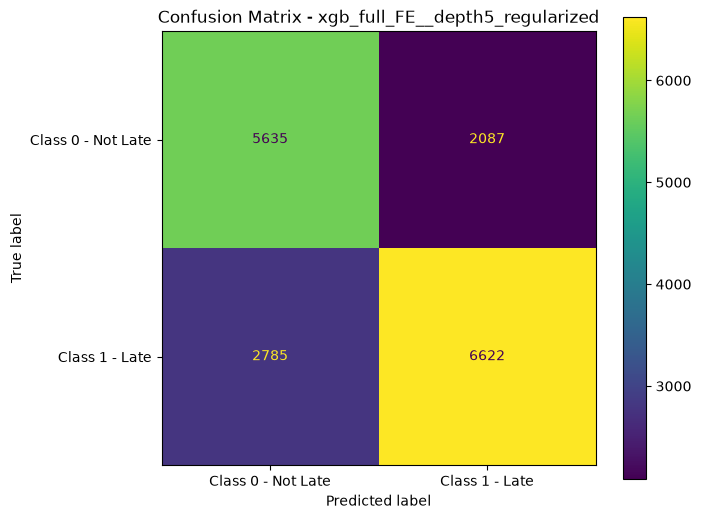

In [ ]:
# Vẽ và lưu confusion matrix của mô hình cuối.
cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0 - Not Late", "Class 1 - Late"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")

plt.title(f"Confusion Matrix - {CHOSEN_CANDIDATE_ID}")

plt.savefig(
    FINAL_MODEL_DIR / "final_confusion_matrix_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


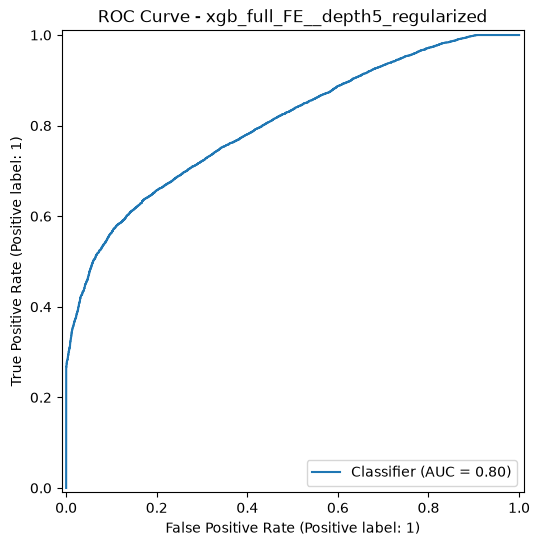

In [ ]:
# Vẽ và lưu ROC curve của mô hình cuối.
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    test_proba,
    ax=ax
)

plt.title(f"ROC Curve - {CHOSEN_CANDIDATE_ID}")

plt.savefig(
    FINAL_MODEL_DIR / "final_roc_curve_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
# Tính và lưu mức độ quan trọng của feature theo loại mô hình cuối.
def get_feature_names_from_artifact(artifact):
    feature_names = artifact["preprocessor"].get_feature_names_out()
    return [
        name.replace("cat__", "").replace("num__", "")
        for name in feature_names
    ]


feature_names = get_feature_names_from_artifact(chosen_artifact)
final_estimator = chosen_artifact["model"]

if chosen_artifact["model_family"] == "xgboost":
    importance_values = final_estimator.feature_importances_
    importance_label = "importance"
else:
    importance_values = np.abs(final_estimator.coef_[0])
    importance_label = "absolute_coefficient"

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    importance_label: importance_values
}).sort_values(importance_label, ascending=False)

feature_importance_df.to_csv(
    FINAL_MODEL_DIR / "final_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)
display(feature_importance_df.head(30))


,feature,importance
1066,days_for_shipment_scheduled,0.365783
284,shipping_mode_Standard Class,0.029209
281,shipping_mode_First Class,0.026557
1058,status_shipping_mode_SUSPECTED_FRAUD__Second C...,0.025006
997,scheduled_shipping_mode_1__First Class,0.023288
1021,scheduled_days_cat_1,0.021416
998,scheduled_shipping_mode_2__Second Class,0.017868
1056,status_shipping_mode_SUSPECTED_FRAUD__First Class,0.017008
283,shipping_mode_Second Class,0.015026
293,order_status_SUSPECTED_FRAUD,0.013997


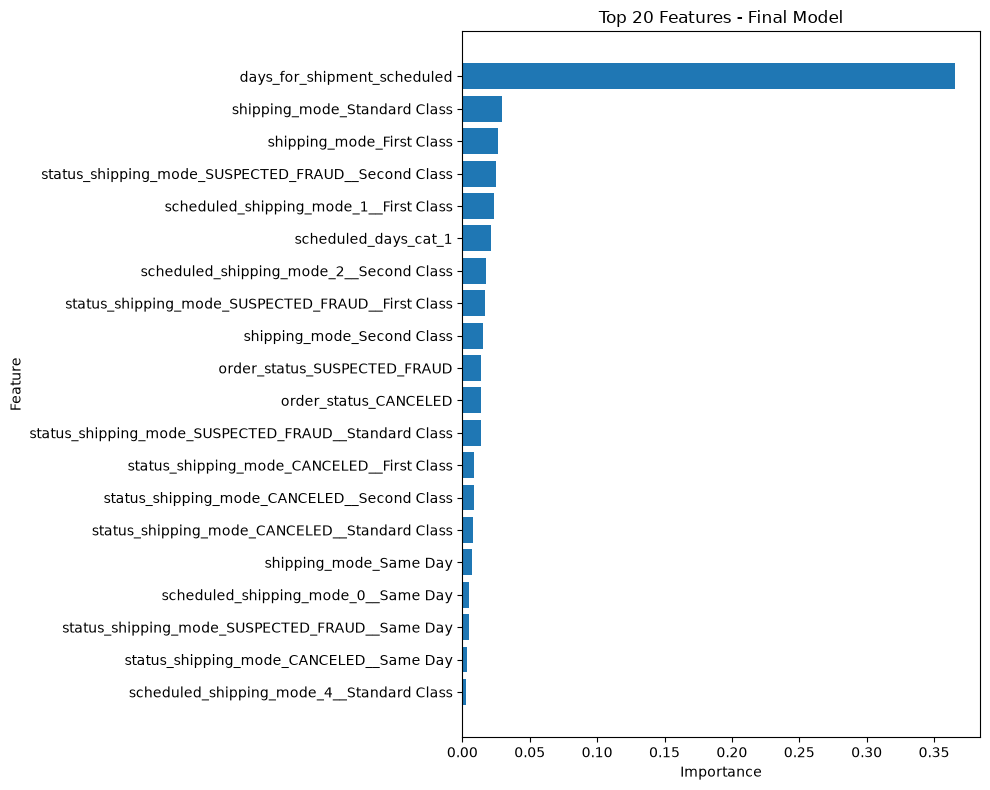

In [ ]:
# Vẽ và lưu biểu đồ top 20 feature.
top_n = 20
value_col = "importance" if "importance" in feature_importance_df.columns else "absolute_coefficient"
plot_df = feature_importance_df.head(top_n).sort_values(value_col)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df[value_col])
plt.xlabel(value_col.replace("_", " ").title())
plt.ylabel("Feature")
plt.title(f"Top {top_n} Features - Final Model")
plt.tight_layout()
plt.savefig(
    FINAL_MODEL_DIR / "final_feature_importance_top20.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
# Lưu artifact và tệp JSON cấu hình của mô hình cuối.
final_artifact_path = FINAL_MODEL_DIR / "final_late_delivery_model_artifact.joblib"

joblib.dump(chosen_artifact, final_artifact_path)

final_config = {
    "chosen_candidate_id": CHOSEN_CANDIDATE_ID,
    "chosen_threshold_type": CHOSEN_THRESHOLD_TYPE,
    "chosen_threshold": CHOSEN_THRESHOLD,
    "target": TARGET_COL,
    "feature_columns": chosen_feature_cols,
    "categorical_features": chosen_artifact["categorical_features"],
    "numerical_features": chosen_artifact["numerical_features"],
    "final_test_metrics": final_test_metrics_df.to_dict(orient="records"),
    "random_state": RANDOM_STATE,
    "model_family": chosen_artifact["model_family"],
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS if chosen_artifact["model_family"] == "xgboost" else None
}

with open(FINAL_MODEL_DIR / "final_model_config.json", "w", encoding="utf-8") as f:
    json.dump(final_config, f, ensure_ascii=False, indent=4)

print("Saved final artifact to:", final_artifact_path)
print("Saved final config to:", FINAL_MODEL_DIR / "final_model_config.json")


Saved final artifact to: ml_outputs\late_delivery_prediction_fe\final_model\final_late_delivery_model_artifact.joblib
Saved final config to: ml_outputs\late_delivery_prediction_fe\final_model\final_model_config.json


## Phần 7. Tạo và dự đoán các đơn hàng mới

- Tạo mười đơn hàng mới từ các giá trị phân loại hợp lệ trong tập train.
- Thiết lập các kịch bản vận chuyển và giá trị đơn hàng khác nhau.
- Áp dụng đúng hàm feature engineering đã dùng khi huấn luyện.
- Dự đoán xác suất và nhãn bằng model cùng threshold cuối.
- Lưu kết quả để có thể kiểm tra hoặc sử dụng ngoài notebook.


In [ ]:
# Tạo một đơn hàng nền từ thống kê của tập train và kiểm tra category hợp lệ.

RAW_MODEL_FEATURES = BASE_CATEGORICAL + BASE_NUMERICAL
train_raw = df.iloc[train_idx].copy()

# Dùng mode của categorical và median của numerical để tạo đơn hàng nền hợp lệ.
base_order = {}
for col in BASE_CATEGORICAL:
    base_order[col] = train_raw[col].mode(dropna=True).iloc[0]

for col in BASE_NUMERICAL:
    base_order[col] = train_raw[col].median()

for col in ["quantity", "days_for_shipment_scheduled", "order_month", "order_day", "order_day_of_week"]:
    base_order[col] = int(round(base_order[col]))

known_shipping_modes = train_raw["shipping_mode"].dropna().unique().tolist()
known_order_statuses = train_raw["order_status"].dropna().unique().tolist()

print("Shipping modes hợp lệ:", known_shipping_modes)
print("Order statuses hợp lệ:", known_order_statuses)
print("Đơn hàng nền:")
display(pd.DataFrame([base_order]))


Shipping modes hợp lệ: ['Standard Class', 'Second Class', 'Same Day', 'First Class']
Order statuses hợp lệ: ['COMPLETE', 'PENDING_PAYMENT', 'CLOSED', 'PROCESSING', 'SUSPECTED_FRAUD', 'ON_HOLD', 'PAYMENT_REVIEW', 'PENDING', 'CANCELED']
Đơn hàng nền:


,market,order_region,order_country,customer_segment,department_name,category_name,product_name,shipping_mode,order_status,quantity,sales_amount,discount_amount,discount_rate,product_unit_price,profit_ratio,days_for_shipment_scheduled,order_month,order_day,order_day_of_week
0,Europe,Western Europe,Estados Unidos,Consumer,Fan Shop,Cleats,Perfect Fitness Perfect Rip Deck,Standard Class,COMPLETE,1,163.990005,14.0,0.1,59.990002,0.27,4,7,16,3


In [ ]:
# Tạo mười kịch bản đơn hàng mới với category hợp lệ và mức numerical khác nhau.

scenario_overrides = [
    {
        "scenario_id": "NEW_ORDER_001",
        "scenario_description": "Đơn tiêu chuẩn, giá trị và lịch giao gần trung vị",
        "shipping_mode": "Standard Class",
        "order_status": "COMPLETE"
    },
    {
        "scenario_id": "NEW_ORDER_002",
        "scenario_description": "Đơn giao trong ngày, giá trị cao",
        "shipping_mode": "Same Day",
        "order_status": "PROCESSING",
        "sales_amount": float(train_raw["sales_amount"].quantile(0.90)),
        "quantity": max(1, int(round(train_raw["quantity"].quantile(0.75))))
    },
    {
        "scenario_id": "NEW_ORDER_003",
        "scenario_description": "Đơn standard có lịch giao dài",
        "shipping_mode": "Standard Class",
        "order_status": "PENDING",
        "days_for_shipment_scheduled": int(train_raw["days_for_shipment_scheduled"].max())
    },
    {
        "scenario_id": "NEW_ORDER_004",
        "scenario_description": "Đơn first class đang chờ thanh toán",
        "shipping_mode": "First Class",
        "order_status": "PENDING_PAYMENT",
        "discount_rate": float(train_raw["discount_rate"].quantile(0.75))
    },
    {
        "scenario_id": "NEW_ORDER_005",
        "scenario_description": "Đơn second class có giá trị thấp",
        "shipping_mode": "Second Class",
        "order_status": "ON_HOLD",
        "sales_amount": float(train_raw["sales_amount"].quantile(0.10)),
        "quantity": max(1, int(round(train_raw["quantity"].quantile(0.25))))
    },
    {
        "scenario_id": "NEW_ORDER_006",
        "scenario_description": "Đơn standard có giá trị rất cao và số lượng lớn",
        "shipping_mode": "Standard Class",
        "order_status": "PROCESSING",
        "sales_amount": float(train_raw["sales_amount"].quantile(0.95)),
        "quantity": max(1, int(round(train_raw["quantity"].quantile(0.90)))),
        "discount_rate": float(train_raw["discount_rate"].quantile(0.50))
    },
    {
        "scenario_id": "NEW_ORDER_007",
        "scenario_description": "Đơn same day có chiết khấu cao",
        "shipping_mode": "Same Day",
        "order_status": "COMPLETE",
        "discount_rate": float(train_raw["discount_rate"].quantile(0.95)),
        "discount_amount": float(train_raw["discount_amount"].quantile(0.90))
    },
    {
        "scenario_id": "NEW_ORDER_008",
        "scenario_description": "Đơn first class đang payment review",
        "shipping_mode": "First Class",
        "order_status": "PAYMENT_REVIEW",
        "sales_amount": float(train_raw["sales_amount"].quantile(0.75)),
        "days_for_shipment_scheduled": int(train_raw["days_for_shipment_scheduled"].min())
    },
    {
        "scenario_id": "NEW_ORDER_009",
        "scenario_description": "Đơn second class nghi ngờ gian lận",
        "shipping_mode": "Second Class",
        "order_status": "SUSPECTED_FRAUD",
        "sales_amount": float(train_raw["sales_amount"].quantile(0.50)),
        "quantity": max(1, int(round(train_raw["quantity"].quantile(0.50))))
    },
    {
        "scenario_id": "NEW_ORDER_010",
        "scenario_description": "Đơn standard đã hủy, giá trị trung bình",
        "shipping_mode": "Standard Class",
        "order_status": "CANCELED",
        "sales_amount": float(train_raw["sales_amount"].quantile(0.50)),
        "discount_rate": float(train_raw["discount_rate"].quantile(0.25))
    }
]

new_order_rows = []
for scenario in scenario_overrides:
    row = base_order.copy()
    row.update({k: v for k, v in scenario.items() if k not in ["scenario_id", "scenario_description"]})
    row["scenario_id"] = scenario["scenario_id"]
    row["scenario_description"] = scenario["scenario_description"]
    new_order_rows.append(row)

new_orders_raw = pd.DataFrame(new_order_rows)

# Đảm bảo các giá trị category tùy chỉnh đều xuất hiện trong train.
for value in new_orders_raw["shipping_mode"].unique():
    if value not in known_shipping_modes:
        raise ValueError(f"Shipping mode không có trong train: {value}")

for value in new_orders_raw["order_status"].unique():
    if value not in known_order_statuses:
        raise ValueError(f"Order status không có trong train: {value}")

display(new_orders_raw)


,market,order_region,order_country,customer_segment,department_name,category_name,product_name,shipping_mode,order_status,quantity,...,discount_amount,discount_rate,product_unit_price,profit_ratio,days_for_shipment_scheduled,order_month,order_day,order_day_of_week,scenario_id,scenario_description
0,Europe,Western Europe,Estados Unidos,Consumer,Fan Shop,Cleats,Perfect Fitness Perfect Rip Deck,Standard Class,COMPLETE,1,...,14.000,0.10,59.990002,0.27,4,7,16,3,NEW_ORDER_001,"Đơn tiêu chuẩn, giá trị và lịch giao gần trung vị"
1,Europe,Western Europe,Estados Unidos,Consumer,Fan Shop,Cleats,Perfect Fitness Perfect Rip Deck,Same Day,PROCESSING,3,...,14.000,0.10,59.990002,0.27,4,7,16,3,NEW_ORDER_002,"Đơn giao trong ngày, giá trị cao"
2,Europe,Western Europe,Estados Unidos,Consumer,Fan Shop,Cleats,Perfect Fitness Perfect Rip Deck,Standard Class,PENDING,1,...,14.000,0.10,59.990002,0.27,4,7,16,3,NEW_ORDER_003,Đơn standard có lịch giao dài
3,Europe,Western Europe,Estados Unidos,Consumer,Fan Shop,Cleats,Perfect Fitness Perfect Rip Deck,First Class,PENDING_PAYMENT,1,...,14.000,0.16,59.990002,0.27,4,7,16,3,NEW_ORDER_004,Đơn first class đang chờ thanh toán
4,Europe,Western Europe,Estados Unidos,Consumer,Fan Shop,Cleats,Perfect Fitness Perfect Rip Deck,Second Class,ON_HOLD,1,...,14.000,0.10,59.990002,0.27,4,7,16,3,NEW_ORDER_005,Đơn second class có giá trị thấp
5,Europe,Western Europe,Estados Unidos,Consumer,Fan Shop,Cleats,Perfect Fitness Perfect Rip Deck,Standard Class,PROCESSING,5,...,14.000,0.10,59.990002,0.27,4,7,16,3,NEW_ORDER_006,Đơn standard có giá trị rất cao và số lượng lớn
6,Europe,Western Europe,Estados Unidos,Consumer,Fan Shop,Cleats,Perfect Fitness Perfect Rip Deck,Same Day,COMPLETE,1,...,49.981,0.25,59.990002,0.27,4,7,16,3,NEW_ORDER_007,Đơn same day có chiết khấu cao
7,Europe,Western Europe,Estados Unidos,Consumer,Fan Shop,Cleats,Perfect Fitness Perfect Rip Deck,First Class,PAYMENT_REVIEW,1,...,14.000,0.10,59.990002,0.27,0,7,16,3,NEW_ORDER_008,Đơn first class đang payment review
8,Europe,Western Europe,Estados Unidos,Consumer,Fan Shop,Cleats,Perfect Fitness Perfect Rip Deck,Second Class,SUSPECTED_FRAUD,1,...,14.000,0.10,59.990002,0.27,4,7,16,3,NEW_ORDER_009,Đơn second class nghi ngờ gian lận
9,Europe,Western Europe,Estados Unidos,Consumer,Fan Shop,Cleats,Perfect Fitness Perfect Rip Deck,Standard Class,CANCELED,1,...,14.000,0.04,59.990002,0.27,4,7,16,3,NEW_ORDER_010,"Đơn standard đã hủy, giá trị trung bình"


In [ ]:
# Áp dụng feature engineering và dự đoán mười đơn hàng mới bằng mô hình cuối.

new_orders_fe = add_non_leakage_features(new_orders_raw)
X_new_orders = new_orders_fe[chosen_feature_cols].copy()

new_order_proba = artifact_predict_proba(chosen_artifact, X_new_orders)
new_order_pred = (new_order_proba >= CHOSEN_THRESHOLD).astype(int)

new_order_predictions = new_orders_raw[
    ["scenario_id", "scenario_description", "shipping_mode", "order_status"]
].copy()
new_order_predictions["predicted_late_probability"] = new_order_proba
new_order_predictions["predicted_late_risk"] = new_order_pred
new_order_predictions["threshold"] = CHOSEN_THRESHOLD

new_order_predictions.to_csv(
    FINAL_MODEL_DIR / "new_order_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

display(
    new_order_predictions.sort_values(
        "predicted_late_probability",
        ascending=False
    )
)


,scenario_id,scenario_description,shipping_mode,order_status,predicted_late_probability,predicted_late_risk,threshold
3,NEW_ORDER_004,Đơn first class đang chờ thanh toán,First Class,PENDING_PAYMENT,0.995433,1,0.43
7,NEW_ORDER_008,Đơn first class đang payment review,First Class,PAYMENT_REVIEW,0.995195,1,0.43
4,NEW_ORDER_005,Đơn second class có giá trị thấp,Second Class,ON_HOLD,0.539107,1,0.43
0,NEW_ORDER_001,"Đơn tiêu chuẩn, giá trị và lịch giao gần trung vị",Standard Class,COMPLETE,0.414026,0,0.43
2,NEW_ORDER_003,Đơn standard có lịch giao dài,Standard Class,PENDING,0.410503,0,0.43
6,NEW_ORDER_007,Đơn same day có chiết khấu cao,Same Day,COMPLETE,0.400778,0,0.43
1,NEW_ORDER_002,"Đơn giao trong ngày, giá trị cao",Same Day,PROCESSING,0.397720,0,0.43
5,NEW_ORDER_006,Đơn standard có giá trị rất cao và số lượng lớn,Standard Class,PROCESSING,0.377327,0,0.43
8,NEW_ORDER_009,Đơn second class nghi ngờ gian lận,Second Class,SUSPECTED_FRAUD,0.001305,0,0.43
9,NEW_ORDER_010,"Đơn standard đã hủy, giá trị trung bình",Standard Class,CANCELED,0.000907,0,0.43


## Phần 8. Phân tích SHAP global

- Nạp SHAP sau khi mô hình cuối đã được chọn.
- Tạo explainer phù hợp với XGBoost hoặc Logistic Regression.
- Lấy mẫu test để kiểm soát thời gian và bộ nhớ.
- Tính mean absolute SHAP cho toàn bộ feature.
- Vẽ bar plot và summary plot của các feature quan trọng nhất.


In [ ]:
# Nạp SHAP và xác nhận loại mô hình cuối cần giải thích.

import shap
import scipy.sparse as sp

print("SHAP version:", shap.__version__)
print("Final model family:", chosen_artifact["model_family"])


SHAP version: 0.52.0
Final model family: xgboost


In [ ]:
# Tạo SHAP explainer phù hợp và tính SHAP values trên mẫu test.

final_preprocessor = chosen_artifact["preprocessor"]
final_estimator = chosen_artifact["model"]
shap_feature_names = get_feature_names_from_artifact(chosen_artifact)

X_test_raw = df_fe.iloc[test_idx][chosen_feature_cols].copy()
SHAP_SAMPLE_SIZE = min(2000, X_test_raw.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
sample_positions = rng.choice(
    np.arange(X_test_raw.shape[0]),
    size=SHAP_SAMPLE_SIZE,
    replace=False
)

X_shap_raw = X_test_raw.iloc[sample_positions].copy()
X_shap_transformed = final_preprocessor.transform(X_shap_raw)

if chosen_artifact["model_family"] == "xgboost":
    explainer = shap.TreeExplainer(final_estimator)
    raw_shap_values = explainer.shap_values(X_shap_transformed)
    shap_values_sample = (
        raw_shap_values[1]
        if isinstance(raw_shap_values, list)
        else raw_shap_values
    )
else:
    # LinearExplainer dùng một mẫu train làm background.
    background_size = min(1000, len(train_idx))
    background_raw = df_fe.iloc[train_idx[:background_size]][chosen_feature_cols].copy()
    background_transformed = final_preprocessor.transform(background_raw)
    explainer = shap.LinearExplainer(final_estimator, background_transformed)
    shap_values_sample = explainer.shap_values(X_shap_transformed)

print("SHAP sample shape:", X_shap_transformed.shape)
print("SHAP values shape:", np.asarray(shap_values_sample).shape)


SHAP sample shape: (2000, 1081)
SHAP values shape: (2000, 1081)


In [ ]:
# Tính và lưu mức độ quan trọng SHAP global theo mean absolute SHAP.

global_shap_importance = pd.DataFrame({
    "feature": shap_feature_names,
    "mean_abs_shap": np.abs(shap_values_sample).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

global_shap_importance.to_csv(
    FINAL_MODEL_DIR / "shap_global_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

display(global_shap_importance.head(30))


,feature,mean_abs_shap
281,shipping_mode_First Class,0.982198
1066,days_for_shipment_scheduled,0.656904
293,order_status_SUSPECTED_FRAUD,0.260462
285,order_status_CANCELED,0.195399
997,scheduled_shipping_mode_1__First Class,0.098144
284,shipping_mode_Standard Class,0.079295
283,shipping_mode_Second Class,0.078347
1073,order_day_cos,0.035769
1068,order_day,0.033184
1065,profit_ratio,0.027649


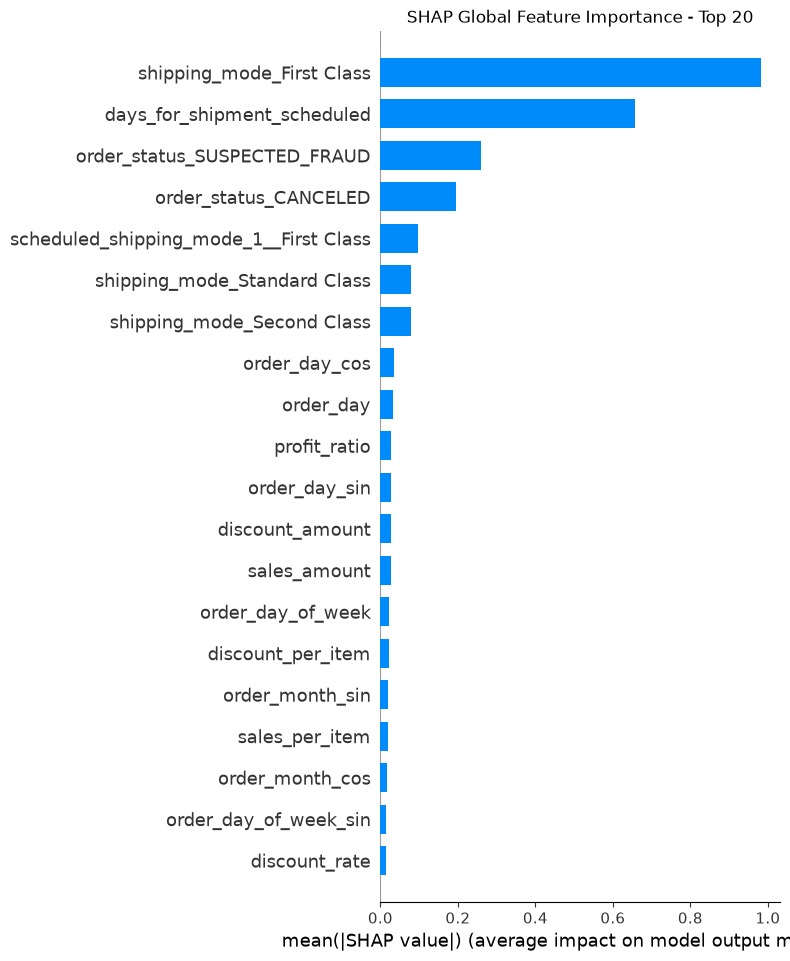

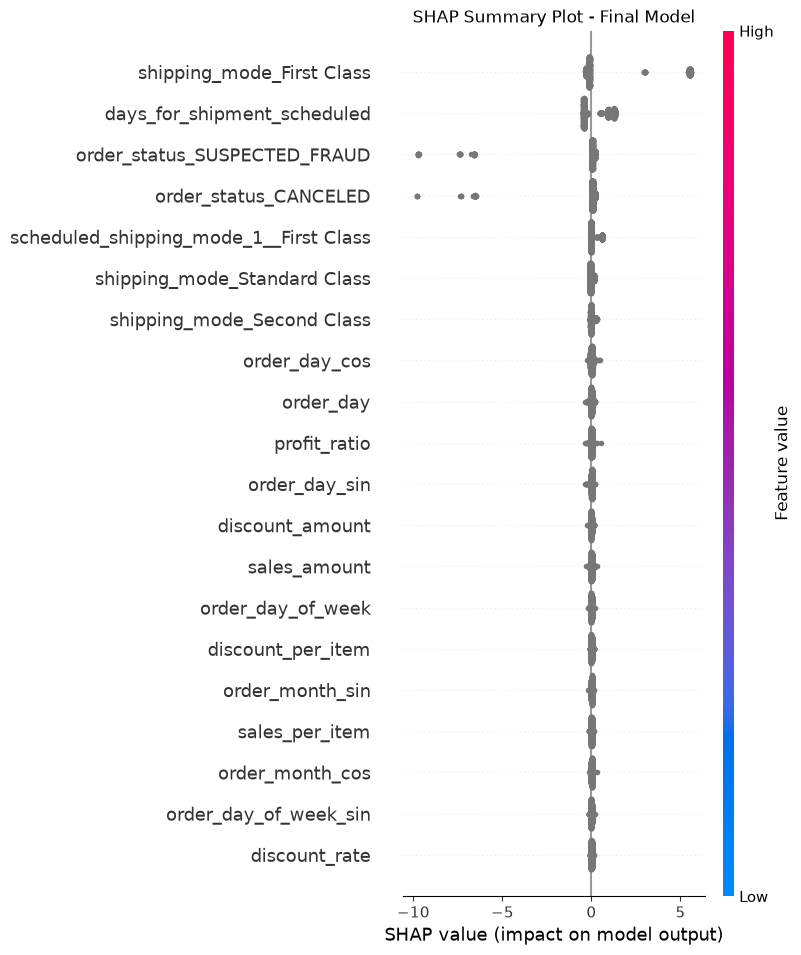

In [ ]:
# Vẽ và lưu biểu đồ SHAP global của mô hình cuối.

plt.figure()
shap.summary_plot(
    shap_values_sample,
    X_shap_transformed,
    feature_names=shap_feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Global Feature Importance - Top 20")
plt.savefig(
    FINAL_MODEL_DIR / "shap_global_importance_bar.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

shap.summary_plot(
    shap_values_sample,
    X_shap_transformed,
    feature_names=shap_feature_names,
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot - Final Model")
plt.savefig(
    FINAL_MODEL_DIR / "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## Phần 9. Chọn đơn hàng và phân tích SHAP local

- Tạo bảng ứng viên từ test cùng xác suất, nhãn dự đoán và nhãn thực tế.
- Chọn tối đa năm đơn hàng đại diện và không trùng nhau.
- Ưu tiên true positive rủi ro cao, true negative chắc chắn, false positive, false negative và trường hợp gần threshold.
- Nếu một nhóm không tồn tại, bổ sung bằng các đơn có xác suất trải đều.
- Tính SHAP local riêng cho từng đơn.
- Tách các yếu tố làm tăng hoặc giảm rủi ro và lưu thành các tệp kết quả.


In [ ]:
# Chọn tối đa năm đơn hàng đại diện theo kết quả đúng, sai và mức độ chắc chắn.

test_case_pool = X_test.copy()
test_case_pool["actual_late_delivery_risk"] = y_test.values
test_case_pool["predicted_late_probability"] = test_proba
test_case_pool["predicted_late_risk"] = test_pred
test_case_pool["distance_to_threshold"] = np.abs(
    test_case_pool["predicted_late_probability"] - CHOSEN_THRESHOLD
)

selection_groups = [
    (
        "true_positive_high_risk",
        test_case_pool[
            (test_case_pool["actual_late_delivery_risk"] == 1) &
            (test_case_pool["predicted_late_risk"] == 1)
        ].sort_values("predicted_late_probability", ascending=False)
    ),
    (
        "true_negative_high_confidence",
        test_case_pool[
            (test_case_pool["actual_late_delivery_risk"] == 0) &
            (test_case_pool["predicted_late_risk"] == 0)
        ].sort_values("predicted_late_probability", ascending=True)
    ),
    (
        "false_positive_high_risk",
        test_case_pool[
            (test_case_pool["actual_late_delivery_risk"] == 0) &
            (test_case_pool["predicted_late_risk"] == 1)
        ].sort_values("predicted_late_probability", ascending=False)
    ),
    (
        "false_negative_near_threshold",
        test_case_pool[
            (test_case_pool["actual_late_delivery_risk"] == 1) &
            (test_case_pool["predicted_late_risk"] == 0)
        ].sort_values("distance_to_threshold", ascending=True)
    ),
    (
        "borderline_closest_to_threshold",
        test_case_pool.sort_values("distance_to_threshold", ascending=True)
    )
]

selected_case_rows = []
selected_indices = set()

for criterion, candidates in selection_groups:
    available = candidates[~candidates.index.isin(selected_indices)]
    if len(available) > 0:
        selected = available.iloc[0].copy()
        selected["selection_criterion"] = criterion
        selected["original_index"] = selected.name
        selected_case_rows.append(selected)
        selected_indices.add(selected.name)

# Bổ sung nếu một loại lỗi không tồn tại hoặc bị trùng với đơn đã chọn.
if len(selected_case_rows) < 5:
    fallback_candidates = test_case_pool.copy()
    fallback_candidates["probability_bin"] = pd.qcut(
        fallback_candidates["predicted_late_probability"],
        q=min(5, fallback_candidates["predicted_late_probability"].nunique()),
        duplicates="drop"
    )
    fallback_candidates = fallback_candidates.sort_values(
        ["probability_bin", "distance_to_threshold"]
    )

    for original_index, row in fallback_candidates.iterrows():
        if original_index in selected_indices:
            continue
        selected = row.copy()
        selected["selection_criterion"] = "probability_range_fallback"
        selected["original_index"] = original_index
        selected_case_rows.append(selected)
        selected_indices.add(original_index)
        if len(selected_case_rows) == 5:
            break

selected_cases = pd.DataFrame(selected_case_rows).reset_index(drop=True)
selected_cases.insert(0, "case_id", [f"SHAP_CASE_{i:02d}" for i in range(1, len(selected_cases) + 1)])

print("Số đơn được chọn:", len(selected_cases))
display(selected_cases[
    [
        "case_id",
        "original_index",
        "selection_criterion",
        "actual_late_delivery_risk",
        "predicted_late_risk",
        "predicted_late_probability",
        "distance_to_threshold"
    ]
])


Số đơn được chọn: 5


,case_id,original_index,selection_criterion,actual_late_delivery_risk,predicted_late_risk,predicted_late_probability,distance_to_threshold
0,SHAP_CASE_01,15898,true_positive_high_risk,1,1,0.999892,0.569892
1,SHAP_CASE_02,78096,true_negative_high_confidence,0,0,0.000342,0.429658
2,SHAP_CASE_03,44887,false_positive_high_risk,0,1,0.935776,0.505776
3,SHAP_CASE_04,35875,false_negative_near_threshold,1,0,0.429969,0.000031
4,SHAP_CASE_05,49496,borderline_closest_to_threshold,0,1,0.430038,0.000038


In [ ]:
# Nội dung: Tính SHAP local và xác nhận dự đoán cho từng đơn hàng đã chọn.

local_explanation_rows = []
local_case_summaries = []

for _, selected_case in selected_cases.iterrows():
    case_id = selected_case["case_id"]
    original_index = selected_case["original_index"]
    X_local_raw = X_test.loc[[original_index]].copy()
    X_local_transformed = final_preprocessor.transform(X_local_raw)

    if chosen_artifact["model_family"] == "xgboost":
        raw_local_shap = explainer.shap_values(X_local_transformed)
        local_shap_values = (
            raw_local_shap[1][0]
            if isinstance(raw_local_shap, list)
            else raw_local_shap[0]
        )
    else:
        local_shap_values = explainer.shap_values(X_local_transformed)[0]

    local_probability = artifact_predict_proba(chosen_artifact, X_local_raw)[0]
    local_prediction = int(local_probability >= CHOSEN_THRESHOLD)

    local_case_summaries.append({
        "case_id": case_id,
        "original_index": original_index,
        "selection_criterion": selected_case["selection_criterion"],
        "actual_late_delivery_risk": int(y_test.loc[original_index]),
        "predicted_late_risk": local_prediction,
        "predicted_late_probability": local_probability,
        "threshold": CHOSEN_THRESHOLD
    })

    for feature, shap_value in zip(shap_feature_names, local_shap_values):
        local_explanation_rows.append({
            "case_id": case_id,
            "original_index": original_index,
            "selection_criterion": selected_case["selection_criterion"],
            "feature": feature,
            "shap_value": float(shap_value),
            "abs_shap_value": float(abs(shap_value))
        })

local_case_summary_df = pd.DataFrame(local_case_summaries)
local_shap_all_df = pd.DataFrame(local_explanation_rows)

display(local_case_summary_df)


,case_id,original_index,selection_criterion,actual_late_delivery_risk,predicted_late_risk,predicted_late_probability,threshold
0,SHAP_CASE_01,15898,true_positive_high_risk,1,1,0.999892,0.43
1,SHAP_CASE_02,78096,true_negative_high_confidence,0,0,0.000342,0.43
2,SHAP_CASE_03,44887,false_positive_high_risk,0,1,0.935776,0.43
3,SHAP_CASE_04,35875,false_negative_near_threshold,1,0,0.429969,0.43
4,SHAP_CASE_05,49496,borderline_closest_to_threshold,0,1,0.430038,0.43


In [ ]:
# Lưu kết quả và hiển thị yếu tố làm tăng hoặc giảm rủi ro cho từng đơn.

local_case_summary_df.to_csv(
    FINAL_MODEL_DIR / "shap_local_selected_cases_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

local_shap_all_df.to_csv(
    FINAL_MODEL_DIR / "shap_local_explanations_all_cases.csv",
    index=False,
    encoding="utf-8-sig"
)

for case_id in local_case_summary_df["case_id"]:
    case_shap = local_shap_all_df[
        local_shap_all_df["case_id"] == case_id
    ]
    positive_factors = case_shap[
        case_shap["shap_value"] > 0
    ].sort_values("shap_value", ascending=False)
    negative_factors = case_shap[
        case_shap["shap_value"] < 0
    ].sort_values("shap_value", ascending=True)

    print("=" * 90)
    print(case_id)
    display(local_case_summary_df[local_case_summary_df["case_id"] == case_id])
    print("Các yếu tố làm tăng rủi ro giao trễ:")
    display(positive_factors.head(10))
    print("Các yếu tố làm giảm rủi ro giao trễ:")
    display(negative_factors.head(10))


SHAP_CASE_01


,case_id,original_index,selection_criterion,actual_late_delivery_risk,predicted_late_risk,predicted_late_probability,threshold
0,SHAP_CASE_01,15898,true_positive_high_risk,1,1,0.999892,0.43


Các yếu tố làm tăng rủi ro giao trễ:


,case_id,original_index,selection_criterion,feature,shap_value,abs_shap_value
281,SHAP_CASE_01,15898,true_positive_high_risk,shipping_mode_First Class,5.330916,5.330916
1066,SHAP_CASE_01,15898,true_positive_high_risk,days_for_shipment_scheduled,1.294981,1.294981
53,SHAP_CASE_01,15898,true_positive_high_risk,order_country_Estonia,1.042624,1.042624
997,SHAP_CASE_01,15898,true_positive_high_risk,scheduled_shipping_mode_1__First Class,0.567441,0.567441
293,SHAP_CASE_01,15898,true_positive_high_risk,order_status_SUSPECTED_FRAUD,0.212986,0.212986
285,SHAP_CASE_01,15898,true_positive_high_risk,order_status_CANCELED,0.211910,0.211910
284,SHAP_CASE_01,15898,true_positive_high_risk,shipping_mode_Standard Class,0.122085,0.122085
1068,SHAP_CASE_01,15898,true_positive_high_risk,order_day,0.053732,0.053732
625,SHAP_CASE_01,15898,true_positive_high_risk,country_shipping_mode_infrequent_sklearn,0.049211,0.049211
1072,SHAP_CASE_01,15898,true_positive_high_risk,order_day_sin,0.031259,0.031259


Các yếu tố làm giảm rủi ro giao trễ:


...

,case_id,original_index,selection_criterion,actual_late_delivery_risk,predicted_late_risk,predicted_late_probability,threshold
4,SHAP_CASE_05,49496,borderline_closest_to_threshold,0,1,0.430038,0.43


Các yếu tố làm tăng rủi ro giao trễ:


,case_id,original_index,selection_criterion,feature,shap_value,abs_shap_value
5396,SHAP_CASE_05,49496,borderline_closest_to_threshold,order_day_sin,0.093065,0.093065
5393,SHAP_CASE_05,49496,borderline_closest_to_threshold,order_day_of_week,0.055430,0.055430
5389,SHAP_CASE_05,49496,borderline_closest_to_threshold,profit_ratio,0.047733,0.047733
4617,SHAP_CASE_05,49496,borderline_closest_to_threshold,order_status_SUSPECTED_FRAUD,0.047011,0.047011
4609,SHAP_CASE_05,49496,borderline_closest_to_threshold,order_status_CANCELED,0.045870,0.045870
4349,SHAP_CASE_05,49496,borderline_closest_to_threshold,order_region_West of USA,0.027645,0.027645
5090,SHAP_CASE_05,49496,borderline_closest_to_threshold,category_shipping_mode_Water Sports__Standard ...,0.016316,0.016316
4376,SHAP_CASE_05,49496,borderline_closest_to_threshold,order_country_Estados Unidos,0.014501,0.014501
5394,SHAP_CASE_05,49496,borderline_closest_to_threshold,order_month_sin,0.012014,0.012014
5397,SHAP_CASE_05,49496,borderline_closest_to_threshold,order_day_cos,0.009655,0.009655


Các yếu tố làm giảm rủi ro giao trễ:


,case_id,original_index,selection_criterion,feature,shap_value,abs_shap_value
5390,SHAP_CASE_05,49496,borderline_closest_to_threshold,days_for_shipment_scheduled,-0.435281,0.435281
4605,SHAP_CASE_05,49496,borderline_closest_to_threshold,shipping_mode_First Class,-0.129600,0.129600
5403,SHAP_CASE_05,49496,borderline_closest_to_threshold,sales_per_item,-0.069602,0.069602
4608,SHAP_CASE_05,49496,borderline_closest_to_threshold,shipping_mode_Standard Class,-0.054481,0.054481
4607,SHAP_CASE_05,49496,borderline_closest_to_threshold,shipping_mode_Second Class,-0.051024,0.051024
5387,SHAP_CASE_05,49496,borderline_closest_to_threshold,discount_rate,-0.028270,0.028270
4719,SHAP_CASE_05,49496,borderline_closest_to_threshold,region_shipping_mode_West of USA__Standard Class,-0.025261,0.025261
5386,SHAP_CASE_05,49496,borderline_closest_to_threshold,discount_amount,-0.020124,0.020124
5321,SHAP_CASE_05,49496,borderline_closest_to_threshold,scheduled_shipping_mode_1__First Class,-0.010731,0.010731
4611,SHAP_CASE_05,49496,borderline_closest_to_threshold,order_status_COMPLETE,-0.008157,0.008157
